# Prologue

Our “Ocular Disease Recognition” project uses [this](https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k) Kaggle source. In this notebook we would like to focus on recognizing and classifying various ocular diseases based on eye images.<br><br>
In order to make this project more fascinating, we will include the element of storytelling<br><br>
**! Please note that all data was acquired from Kaggle and we do not own any of it. This story is purely fictional and is intended to make project reviewing more entertaining**

# A long time ago in a galaxy far, far away...

Our story revolves around the world of ophthalmology and how data science is being used to transform eye health diagnosis. In the past, diagnosing eye diseases like diabetic retinopathy, glaucoma, and cataracts required manual examination, but with the growing availability of eye image data, data scientists have emerged as powerful allies in detecting these conditions more quickly and accurately. Even in our real-world [medical applicaitons](https://pubmed.ncbi.nlm.nih.gov/33165420/), AI plays a huge role.

Now, imagine a world where AI-powered eye exams could revolutionize preventive care—by recognizing diseases in their early stages and saving millions of people from vision loss. We introduce a protagonist, Dr. Iris, an ophthalmologist who has embraced machine learning and is working on a research project to classify ocular diseases using the ODIR-5K dataset.

-------------

In [1]:
!pip install -q kaggle
!pip install -q easyimages
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k
!unzip -q /content/ocular-disease-recognition-odir5k.zip -d .
!pip install ace-tools
!pip install -q kaggle tensorflow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
 99% 1.61G/1.62G [00:16<00:00, 115MB/s] 
100% 1.62G/1.62G [00:16<00:00, 104MB/s]


Dr. Iris, excited to dive into the data science journey, begins by importing the essential libraries needed to process and analyze the ocular disease dataset. She imports various tools, including pandas for data manipulation, numpy for numerical operations, seaborn and matplotlib for visualization, and statistical libraries like scipy for hypothesis testing.

In [2]:
import numpy as np
import pandas as pd
import os
import random
import itertools
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img,img_to_array

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Reshape, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras.metrics import Precision
from keras.metrics import AUC
from sklearn.metrics import roc_curve, auc


from sklearn.utils.class_weight import compute_class_weight
import shutil
from scipy import stats
from scipy.stats import chi2_contingency
import seaborn as sns
import warnings
from PIL import Image
from cv2 import Laplacian, CV_64F
from PIL import ImageFilter

# What is the Final Goal?

Dr. Iris, why are you doing this, may a reader ask. In roder to treat the patients efficiently, she needs to know about the "enemy" - the ocular diseases - as much as possible. The main idea is to develop a machine learning model for binary classification to distinguish between normal and cataract-affected eyes. Dr. Iris wants to do so by leveraging a Convolutional Neural Network (CNN) architecture and utilizing a pretrained Keras model as the backbone. Then she can fine-tune this pretrained model using the ODIR dataset to adapt it for the specific task of classifying eye conditions.

Dr. Iris utilized Keras's flow_from_dataframe functionality to streamline the preprocessing pipeline, enabling the generation of augmented and scaled images directly from a structured dataframe. Furthermore, she applied various preprocessing parameters to adjust and enhance the images, ensuring the input data is optimized for training. By combining the feature extraction power of CNNs with transfer learning and robust preprocessing techniques, Dr. Iris hopes that this project will deliver an accurate and efficient solution for binary classification of eye conditions.

# Tabular Data Exploration

## Loading Tabular Data

Dr. Iris is working with a large collection of eye images labeled with various ocular diseases. Her goal is to train a machine learning model that can diagnose diseases by analyzing the visual features of these eye images.

The overall dataset includes:
1. Images of the fundus (back part of the eye) that can show signs of disease.
2. Labels such as Normal, Diabetes, Glaucoma, and more.

Dr. Iris will work with tabular data first. She loads the patients' medical records. She has to preprocess, clean, and prepare these for modeling.

Dr. Iris suspects that she will face some challenges with denitifying hidden patterns within her data. Even asking the right questions can be tricky!

Lets set up our file paths and take a look at some of the the data we have right now:

In [3]:
image_dir = '/content/preprocessed_images'
csv_dir = '/content/full_df.csv'

df = pd.read_csv(csv_dir)
df.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


Dr. Iris, has a first glimpse of the medical records she's working with, and decides to take a look at the first few entries of the dataset.

As the table loads on her screen, she begins to understand the basic layout: each row represents a patient, and the columns contain information like their age, sex, and diagnostic results for various ocular diseases. In these records she also notices the file paths to the images of the patients' eyes, which (she suspects) will be important for training her model.

This initial view helps Dr. Iris to confirm that the dataset is properly loaded and that the columns, on which she will rely for analysis, are well-represented and organized. She feels like the dataset is ready for further exploration and cleaning

Alright, medical records are uploaded. Dr. Iris begins her analysis by taking a moment to understand the full scope of the dataset she's working with. To do this, she runs a command that gives her a comprehensive statistical overview of every column in the dataset—both numerical and categorical. What can she find there?

In [4]:
df.describe(include='all')

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
count,6392.000000,6392.000000,6392,6392,6392,6392,6392,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392.000000,6392,6392,6392,6392
unique,NaN,NaN,2,3358,3358,196,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6392,8,8,6392
top,NaN,NaN,Male,0_left.jpg,0_right.jpg,normal fundus,normal fundus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
freq,NaN,NaN,3424,2,2,2796,2705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2873,2873,1
mean,2271.150814,57.857947,NaN,NaN,NaN,NaN,NaN,0.328692,0.332134,0.062109,0.062891,0.049906,0.031758,0.047872,0.248436,NaN,NaN,NaN,NaN
std,1417.559018,11.727737,NaN,NaN,NaN,NaN,NaN,0.469775,0.471016,0.241372,0.242786,0.217768,0.175370,0.213513,0.432139,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,920.750000,51.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,2419.500000,59.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,3294.000000,66.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN


As the results come in, she examines the output, which reveals a lot more than just averages and counts. The summary table shows her:

- Mean, median, and standard deviation for the numerical fields like Patient's Age
- The most common category values for fields such as gender and disease type, helping her to quickly identify which diseases dominate the dataset.
	•	Unique counts for categorical data, revealing any unexpected variety or even potential data entry errors.

This step helps Dr. Iris quickly get a sense of the range of Patient's Sex, their distributions, and any outliers or anomalies that might need further attention.

With this knowledge in hand, she's more confident in how she should proceed with deeper analysis and model building.

----

## Organizing and Converting



Dr. Iris quickly checks the data types of each column. She confirms that Patient's Age is an integer, suitable for analysis, while Diagnostic Keywords for left and right eyes are objects.

She notes that she has to convert categorical columns later for optimization. Like Patient's Sex can be converted to a integers

In [5]:
df.dtypes

,0
ID,int64
Patient Age,int64
Patient Sex,object
Left-Fundus,object
Right-Fundus,object
Left-Diagnostic Keywords,object
Right-Diagnostic Keywords,object
N,int64
D,int64
G,int64


Dr. Iris decides to make the dataset more readable by renaming the cryptic column labels. She changes abbreviations like N to “Normal” and D to “Diabetes,” making it easier to understand what each column represents at a glance. Not only this improves clarity for her analysis, but also ensures that anyone else working with the dataset can immediately recognize which column corresponds to each ocular condition

In [6]:
# renaming columns in the DataFrame to make them more readable
df = df.rename(columns={
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'Age Degeneration',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
})

Dr. Iris prepares her dataset for machine learning by converting the Patient's Sex column into a numerical format where female is 1 and male is 0. This will simplify the categorical data into binary values.

Why do this? To allow the models to process gender information effectively, ensuring that the sex of the patient can be used as a feature without causing any problems during training

In [7]:
df['Patient Sex'] = df['Patient Sex'].map({'Female': 1, 'Male': 0})

Dr. Iris wants to understand how balanced the dataset is across different diseases. She sums the columns representing each health condition. By calculating the percentage of each class, she quickly identifies whether any disease type is over- or under-represented

The results show that **Diabetes**, **Normal**, and **Other conditions** are overrepresented comparing to other  diseases.

In [8]:
# calculating the distribution of each health class by summing the respective columns
class_distribution = df[['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']].sum()
total_samples = len(df) # total number of samples for reference

class_distribution_percentage = (class_distribution / total_samples) * 100 # percentage distribution for each class

class_balance_df = pd.DataFrame({       # creating a DataFrame for easier analysis
    'Class Count': class_distribution,
    'Percentage of Total (%)': class_distribution_percentage
})
print("Health Class Distribution Analysis:")
class_balance_df

Health Class Distribution Analysis:


,Class Count,Percentage of Total (%)
Normal,2101,32.869212
Diabetes,2123,33.213392
Glaucoma,397,6.210889
Cataract,402,6.289111
Age Degeneration,319,4.990613
Hypertension,203,3.175845
Myopia,306,4.787234
Other,1588,24.843554


From the previous look at the medical records, Dr. Iris knows that some diseases, like **Diabetes**, are more common than others. This could lead to a biased model. So she calculates class weights for each health condition.

First, she identifies the most dominant disease for each patient by finding the column with the highest value in their diagnostic data.

Next, she assigns higher weights to under-represented classes, like **Cataract**, ensuring that the model will pay more attention to rarer diseases

In [9]:
y = df[['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']].idxmax(axis=1)

class_weights = compute_class_weight( # class weights based on the updated target variable
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = dict(zip(np.unique(y), class_weights)) # mapping them to the corresponding disease
class_weight_dict

{'Age Degeneration': 2.99250936329588,
 'Cataract': 2.481366459627329,
 'Diabetes': 0.3763542157324541,
 'Glaucoma': 2.343108504398827,
 'Hypertension': 9.183908045977011,
 'Myopia': 3.1089494163424125,
 'Normal': 0.3802950975725845,
 'Other': 0.8937360178970917}

## Handling Missing Data

Dr. Iris runs a quick check for missing values in her dataset by calculating the total number of **NaN** (Not a Number) and **null** values across all columns. This step helps her identify any gaps in the data that need to be addressed before proceeding with analysis.

This is interesting and rare, medical records do not contain any missing values!

In [10]:
df.isna().sum() + df.isnull().sum()

,0
ID,0
Patient Age,0
Patient Sex,0
Left-Fundus,0
Right-Fundus,0
Left-Diagnostic Keywords,0
Right-Diagnostic Keywords,0
Normal,0
Diabetes,0
Glaucoma,0


Every column is fully populated, so she doesn't have to spend time on imputation or data cleaning for missing values. With this solid foundation, she can proceed directly to deeper analysis and model building. But does she need all these data points?

## Visualization

Dr. Iris wants to understand the **distribution of labels** in the dataset. Because she alreaady knows about diseases' imbalance, she reviews the count for each label to understand the **balance of the dataset**

In [11]:
df['labels'].value_counts()

,count
labels,
['N'],2873
['D'],1608
['O'],708
['C'],293
['G'],284
['A'],266
['M'],232
['H'],128


Dr. Iris decides to visualize the **distribution of the labels** in her dataset using a pie chart to quickly assess how evenly distributed the conditions are. Thsis pie chart provides an intuitive snapshot of the dataset and gives her a clear understanding of the proportional representation of each disease.

As seen in the tabular form, a bit less than half of the patients are healthy with "N" dominating the pie chart. But nearly a quarter of the chart shows "D", which stands for **Diabetes**

<Axes: ylabel='count'>

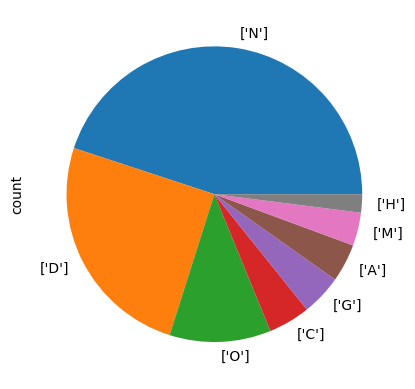

In [12]:
df['labels'].value_counts().plot.pie()

Dr. Iris creates another pie chart to visualize the distribution of **Patient Sex** in the dataset. By plotting the counts of males and females, she quickly sees that the dataset is balanced.

<Axes: ylabel='count'>

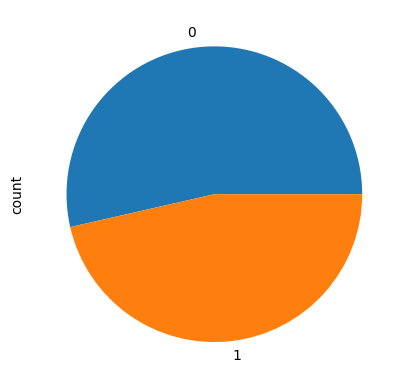

In [13]:
df['Patient Sex'].value_counts().plot.pie()

Dr. Iris now decides to explore the age distribution of patients. She visualizes the spread of **Patient Age** to understand how different age groups (including information about patient sex) are represented.

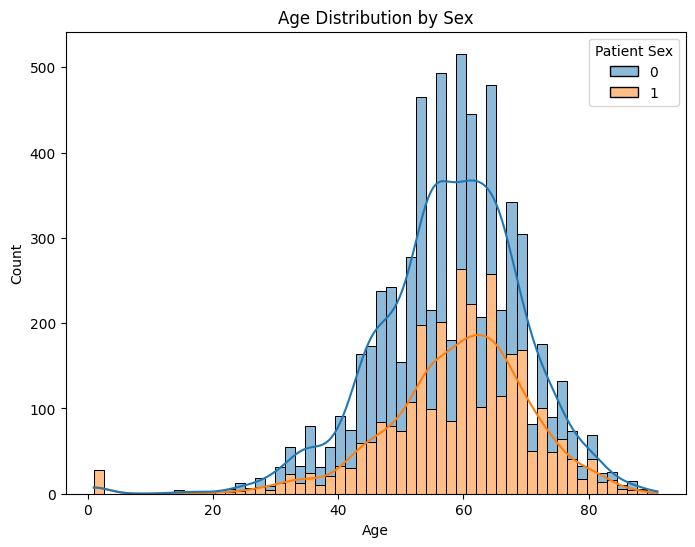

In [14]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Patient Age', hue='Patient Sex', multiple="stack", kde=True)
plt.title('Age Distribution by Sex')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The plot looks more or less normally distributed and skewed towards older ages. Dr. Iris notices some suspicious "young" patients that look like outliers. She wants to have a closer look at this:

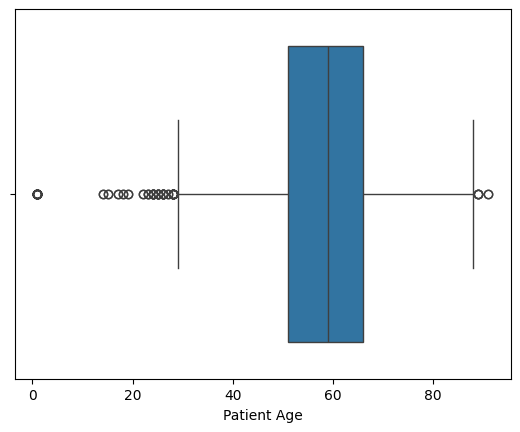

In [15]:
sns.boxplot(data=df, x='Patient Age');

Indeed! Dr. Iris notices that, although there are a couple "older" outliers, the majority are around 20 or even younger.

----

Dr. Iris wants to go deeper into the relationships between different ocular conditions by creating a **correlation heatmap**.

The heatmap uses a color gradient to display the strength of these correlations. A value close to **1** indicates a strong positive correlation, meaning those diseases tend to occur together, while a value close to **-1** suggests a negative correlation, meaning they rarely appear together

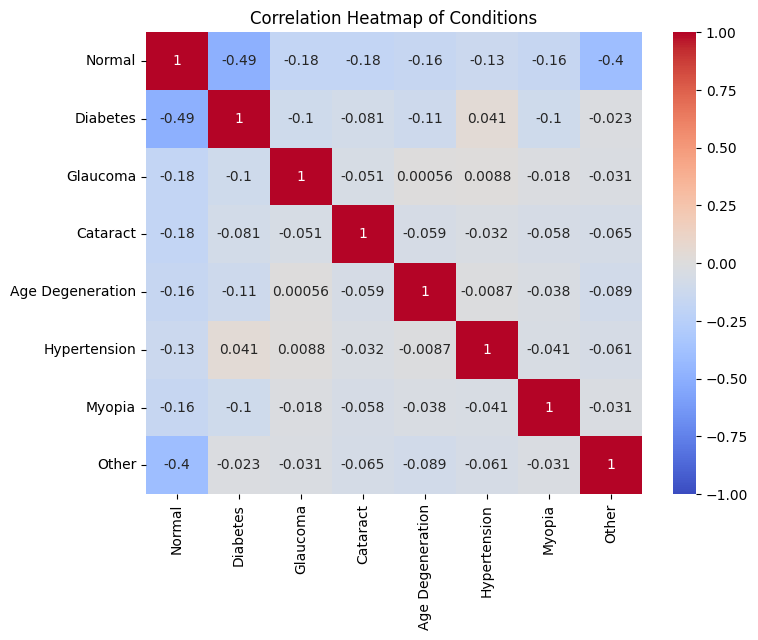

In [16]:
# Heatmap of diseases (in general)
label_columns = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']
plt.figure(figsize=(8, 6))
correlation_matrix = df[label_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Conditions')
plt.show()

## Outliers

Dr. Iris now is interested in identifying **outliers**.

She starts with patient age data. To do this, she calculates the **Interquartile Range (IQR)**, which is the difference between the **first (Q1)** and **third quartile (Q3)** of the age distribution.

Based on the results, she found that the **lower bound** for potential outliers is **28.5 years** and the **upper bound** is **88.5 years**.

This means that any patients younger than 28.5 or older than 88.5 are considered **outliers** based on the age distribution.

In [17]:
Q1 = df['Patient Age'].quantile(0.25)
Q3 = df['Patient Age'].quantile(0.75)
IQR = Q3 - Q1
print(f'{Q1 - 1.5*IQR} {Q3 + 1.5*IQR}')

28.5 88.5


Dr. Iris wants to calculate the proportion of patients who fall outside the age bounds that she found above. For this, she calculates the percentage of patients who are younger than 28.5 and those older than 88.5

In [18]:
print(len(df[df['Patient Age'] < 28.5]) / len(df) * 100) # percentage of patients who are younger than 28.5
print(len(df[df['Patient Age'] > 88.5]) / len(df) * 100) # percentage of patients who are older than 88.5

1.2672090112640801
0.09386733416770963


Since the outliers make up less than 5% of the entire dataset, Dr. Iris decides it is safe to exclude them from the training data. This will reduce the chance of skewed results caused by a small, extreme portion of the dataset.

-----

She now resets the index of her DataFrame to ensure the dataset has a continuous index to avoid any confusion caused by the original indexing

In [19]:
df.reset_index(drop=True, inplace=True)

## Feature Engineering

### Categories for severity based on diagnostic keywords for left and right eye

Dr. Iris decides to assign the severity levels to each patient's left and right eyes based on diagnostic keywords. She categorizes conditions as normal, mild, moderate, or severe, and stores these in the columns left-diagnostic-category and right-diagnostic-category. If no severity is found, it is marked as none

In [20]:
diagnostic_keyword_features = ['Left-Diagnostic Keywords', 'Right-Diagnostic Keywords']
diagnostic_severity_features = ['left-diagnostic-category', 'right-diagnostic-category']
df['left-diagnostic-category'] = 'none'
df['right-diagnostic-category'] = 'none'
for keyword_feature, severity in zip(diagnostic_keyword_features, diagnostic_severity_features):
  print(keyword_feature)
  no_severity_count = 0
  normal_count = 0
  mild_count = 0
  moderate_count = 0
  severe_count = 0
  for i in range(len(df)):
    keyword = df.loc[i, keyword_feature]
    # print(i, keyword)
    if 'normal fundus' in keyword:
      df.loc[i, severity] = 'normal'
      normal_count += 1
    elif 'mild' in keyword:
      df.loc[i, severity] = 'mild'
      mild_count += 1
    elif 'moderate' in keyword:
      df.loc[i, severity] = 'moderate'
      moderate_count += 1
    elif 'severe' in keyword:
      df.loc[i, severity] = 'severe'
      severe_count += 1
    else:
      df.loc[i, severity] = 'none'
      no_severity_count += 1

  print(f'normal: {normal_count}; mild: {mild_count}; moderate: {moderate_count}; severe: {severe_count}; none: {no_severity_count}')

Left-Diagnostic Keywords
normal: 2898; mild: 517; moderate: 917; severe: 169; none: 1891
Right-Diagnostic Keywords
normal: 2777; mild: 540; moderate: 960; severe: 162; none: 1953


### Categorizing the 'Patient Age' variable

Dr. Iris decides to bin Patient Age. She uses Sturge's rule to determine the optimal number of bins.

This method helps her create a well-balanced histogram that effectively represents the data without oversimplifying or overcomplicating the visualization

In [21]:
n = df['Patient Age'].shape[0]
# by Sturge's rule
nbins = int(1 + 3.322*np.log(n))
nbins

30

Dr. Iris checks the **minimum age** is 1 and the **maximum age** is 91, giving her the range of interest.

Using the number of bins she calculated before, she determines the bin width

In [22]:
print(f'minimum age is {df["Patient Age"].min()}, maximum age is {df["Patient Age"].max()}')
start = 28
end = 90
bin_width = int((end - start) / nbins)
bin_width

minimum age is 1, maximum age is 91


2

In [23]:
# We'll adjust the range
start = 28
end = 90
bin_width = int((end - start) / nbins)
bin_width

2

Dr. Iris finishes the binning process by calculating the bin edges. This gives her an evenly spaced set of bins that will be used to visualize the distribution of patient ages

In [24]:
bins = [start + i*bin_width for i in range(nbins+2)]
bins = [i for i in range(start, end+bin_width, bin_width)]
print(bins)

[28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90]


### Age Outliers Removal

To ensure that her analysis focuses on the adult population and eliminates potential outliers or data entry errors, Dr. Iris decided to excluded all patients under the age of 20. This step allows her to focus on the age range that is most relevant to common ocular diseases

Original dataset size: 6392
Dataset size after removing people under 20: 6354
Number of people under 20 removed: 38


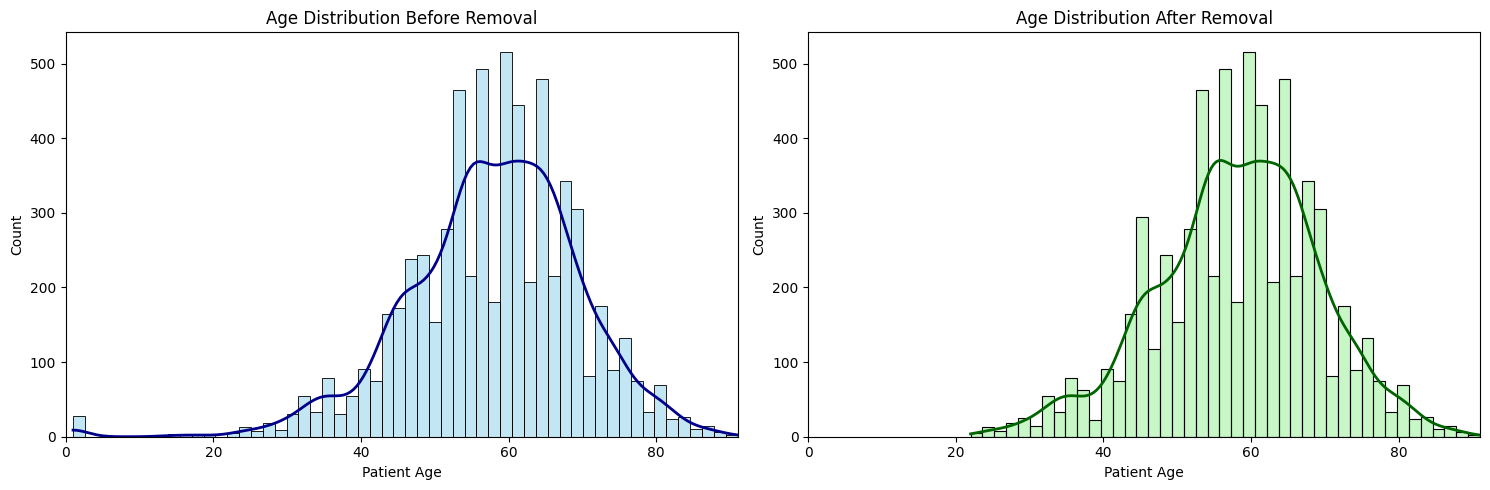


Summary statistics of cleaned age data:
count    6354.000000
mean       58.173434
std        11.014985
min        22.000000
25%        51.000000
50%        59.000000
75%        66.000000
max        91.000000
Name: Patient Age, dtype: float64


In [25]:
def age_outliers(df, age_column='Patient Age'):
    print(f"Original dataset size: {len(df)}")
    under_20 = df[df[age_column] < 20]
    df_clean = df[df[age_column] >= 20]

    print(f"Dataset size after removing people under 20: {len(df_clean)}")
    print(f"Number of people under 20 removed: {len(under_20)}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df[age_column], kde=True, ax=ax1, color='skyblue')
    ax1.lines[0].set_color('darkblue')
    ax1.lines[0].set_linewidth(2)
    ax1.set_title("Age Distribution Before Removal")
    ax1.set_xlim(0, df[age_column].max())
    sns.histplot(df_clean[age_column], kde=True, ax=ax2, color='lightgreen')
    ax2.lines[0].set_color('darkgreen')
    ax2.lines[0].set_linewidth(2)
    ax2.set_title("Age Distribution After Removal")
    ax2.set_xlim(0, df[age_column].max())
    plt.tight_layout()
    plt.show()
    return df_clean, under_20

cleaned_df, removed_data = age_outliers(df)
print("\nSummary statistics of cleaned age data:")
print(cleaned_df['Patient Age'].describe())
cleaned_df = cleaned_df.reset_index(drop=True)

Dr. Iris reviews the summary statistics of the cleaned dataset after removing patients under 20 years old:

- **Count**: 6,354 patients remain, which is good
- **Mean Age**: around 58 years, which indicates that most patients are middle-aged or older
- **Standard Deviation**: 11.01, which shows moderate variability in age
- **Age Range**: The youngest patient is now 22, and the oldest is 91.
- **Quartiles**: 25% of patients are younger than 51, 50% (median) are younger than 59, and 75% are younger than 66.

These statistics confirm that the dataset is now focused on a more relevant age group, aligning with the goals of her analysis

----

Dr. Iris now decided to reepeat her analysis of the diseases' distribution in the cleaned dataset. She visualizes this using a pie chart to illustrate the proportion of each disease in the dataset, labeling the chart with percentages for easy interpretation

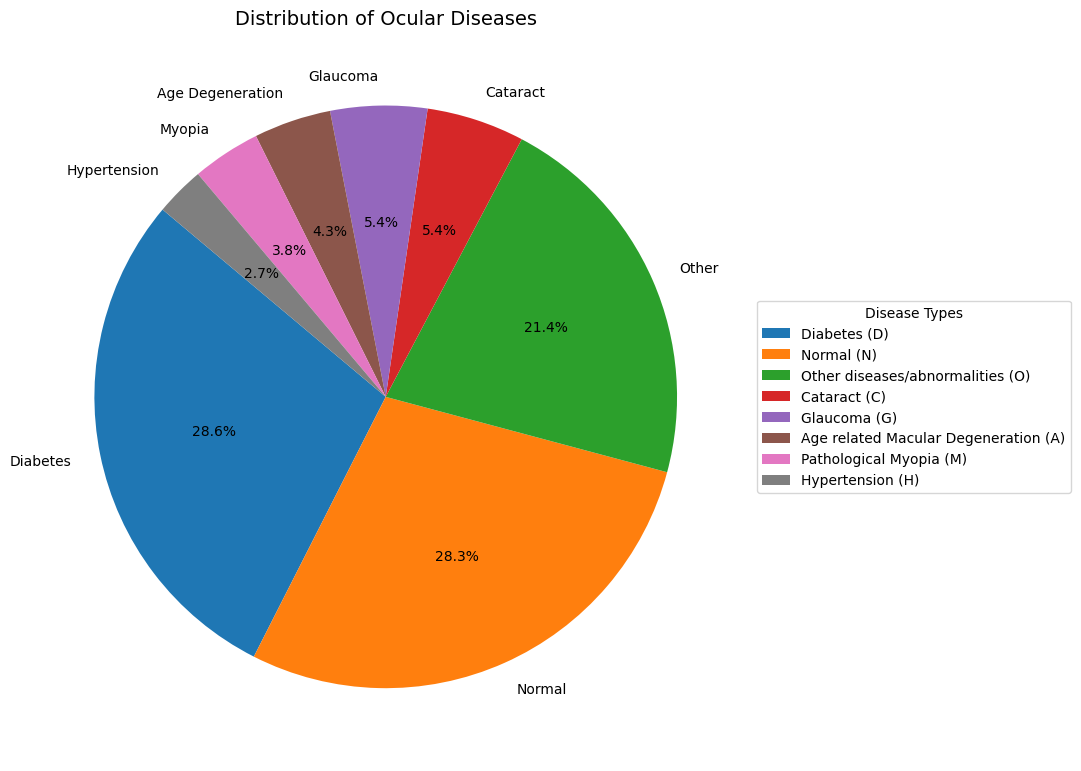

Distribution of Diseases:
Diabetes (D): 2119
Normal (N): 2095
Other diseases/abnormalities (O): 1586
Cataract (C): 402
Glaucoma (G): 397
Age related Macular Degeneration (A): 317
Pathological Myopia (M): 281
Hypertension (H): 203


In [26]:
disease_counts = cleaned_df[['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']].sum().sort_values(ascending=False)
disease_labels = {
    'Normal': 'Normal (N)',
    'Diabetes': 'Diabetes (D)',
    'Glaucoma': 'Glaucoma (G)',
    'Cataract': 'Cataract (C)',
    'Age Degeneration': 'Age related Macular Degeneration (A)',
    'Hypertension': 'Hypertension (H)',
    'Myopia': 'Pathological Myopia (M)',
    'Other': 'Other diseases/abnormalities (O)'
}
fig, ax = plt.subplots(figsize=(10, 8))
plt.pie(disease_counts.values, labels=disease_counts.index, autopct='%1.1f%%', startangle=140)
plt.legend([disease_labels[disease] for disease in disease_counts.index], title="Disease Types", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Ocular Diseases', fontsize=14, y=1)
plt.tight_layout()
plt.show()

total_patients = len(cleaned_df)
print("Distribution of Diseases:")
for disease, count in disease_counts.items():
    print(f"{disease_labels[disease]}: {count}")

Dr.Iris finds the top conditions: **Diabetes** (2,119 cases) and **Normal** (2,095 cases). Other significant findings include 1,586 cases of **Other diseases/abnormalities**, which are not explicitly listed.

This concludes tabular data exploration

# Images Exploration


With the tabular exploration finished, Dr. Iris shifts her focus to the next important part of the project: **image exploration**.

She prepares to dive into the eye images associated with each patient, knowing that visual data will play a pivotal role in training her model to detect and classify ocular diseases based on these diagnostic images

## Loading Images

Dr. Iris begins by loading the directories containing the **training** and **testing images** for her project. These images, paired with the diagnostic labels from the tabular data, will be the foundation for training a machine learning model that can **predict ocular diseases** based on eye scans

In [27]:
train_dir = '/content/ODIR-5K/ODIR-5K/Training Images' # directory for training images
test_dir = '/content/ODIR-5K/ODIR-5K/Testing Images'   # directory for testing images

train_files = os.listdir(train_dir)                    # these will be our training images
test_files = os.listdir(test_dir)                      # these will be our testing images

She constructs the full path to the first image in the training dataset and visualizes it.

With this successful preview, Dr. Iris is ready to start pre-processing the entire dataset of images, preparing them for training her model

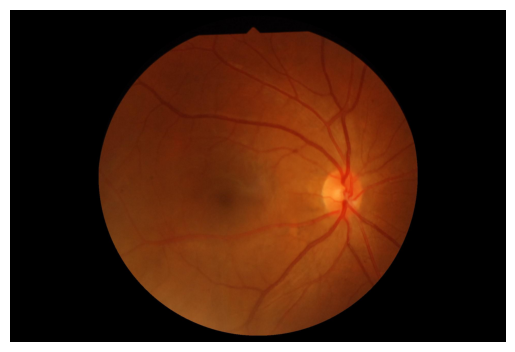

In [28]:
# Dr. Iris picks at some random image from the dataset
image_path = os.path.join(train_dir, train_files[0])
img = Image.open(image_path)
img.show()

plt.imshow(img)
plt.axis('off')
plt.show()

Dr. Iris now wants to load all of the training and testing images into memory to systematically load and inspect the images that will be used to train and evaluate her machine learning model.

Then Dr. Iris proceeds to build lists (`train_images` and `test_images`) where all the images from both sets will be stored

In [29]:
# list of training images
train_images = []
for file in train_files:
    image_path = os.path.join(train_dir, file)
    img = Image.open(image_path)

In [30]:
# creating a list of test images
test_path = os.path.join(test_dir, test_files[0])
img = Image.open(test_path)
img.show()

test_images = []
for file in test_files:
    test_path = os.path.join(test_dir, file)
    img = Image.open(test_path)

## Initial Exploration

Dr. Iris quickly checks the columns of her cleaned dataset and inspects the first few entries to ensure everything is properly formatted. This step gets a better understanding on what the schema of the datasets look like

In [31]:
print(cleaned_df.columns)
# inspect the labels column to check the format
cleaned_df['labels'].head()

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'Normal',
       'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension',
       'Myopia', 'Other', 'filepath', 'labels', 'target', 'filename',
       'left-diagnostic-category', 'right-diagnostic-category'],
      dtype='object')


,labels
0,['N']
1,['N']
2,['D']
3,['D']
4,['D']


Dr. Iris decides to count the occurrences of each disease, from which she quickly gets an overview of how often each condition appears in the dataset. She visualizes the 8 columns that correspond to each disease.

Next, she will use the labels column to check for inconsistencies between patient data and image data

labels
N    2864
D    1605
O     708
C     293
G     284
A     264
M     208
H     128
Name: count, dtype: int64


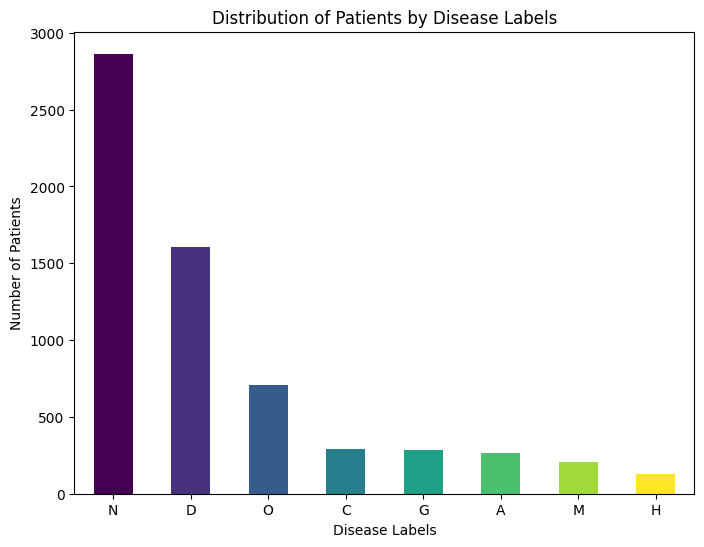

In [32]:
# split the labels column into seperate diseases
cleaned_df['labels'] = cleaned_df['labels'].astype(str).apply(lambda x: eval(x) if x.startswith('[') and x.endswith(']') else x)

# expand the labels column so that each disease gets its own row
df_exploded = cleaned_df.explode('labels')

# count the occurrences of each disease
disease_counts = df_exploded['labels'].value_counts()

# display the frequency of each disease
print(disease_counts)

# plot the distribution of each disease
plt.figure(figsize=(8, 6))
disease_counts.plot(kind='bar', color=plt.cm.viridis(np.linspace(0, 1, len(disease_counts))))
plt.title('Distribution of Patients by Disease Labels')
plt.xlabel('Disease Labels')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


Dr. Iris again observes from the graph that **Normal (N)** cases dominate the dataset, while **Diabetes (D)** is the most frequent disease. This imbalance suggests that the model might be biased towards predicting normal eyes, making it less effective at identifying less common diseases like **Pathological Myopia (M)** or **Hypertension (H)**. To address this, Dr. Iris considers future strategies like **resampling** or **class weighting** during model training to ensure better generalization

---------------

Next, Dr. Iris previews a few of the training images to visually inspect their quality and content

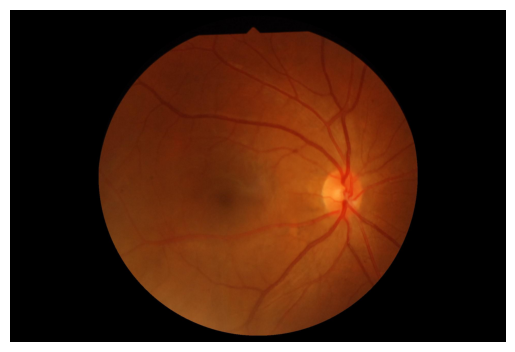

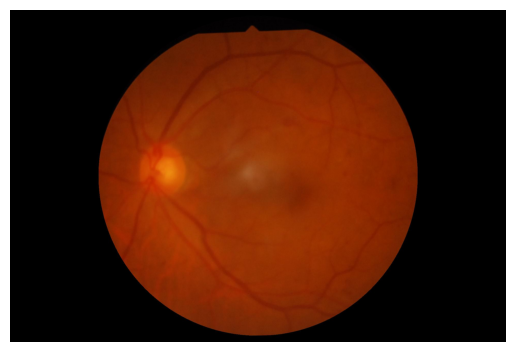

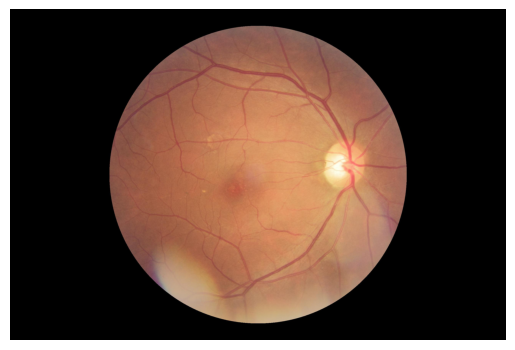

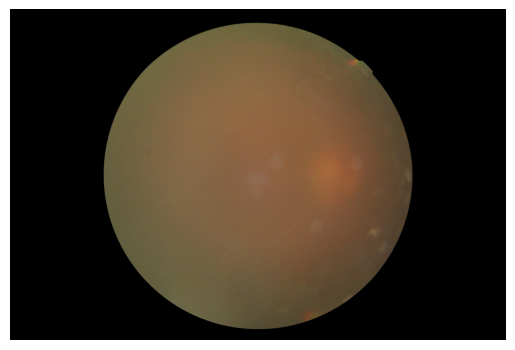

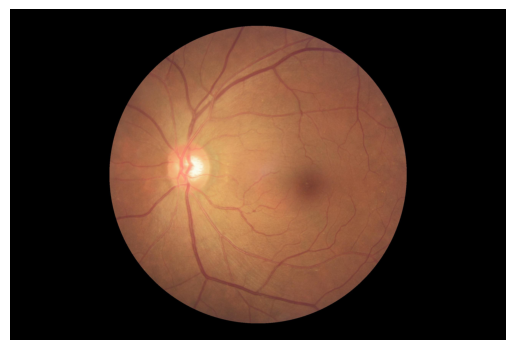

In [33]:
for i in range(0,5):
  image_path = os.path.join(train_dir, train_files[i])
  img = Image.open(image_path)
  img.show()

  plt.imshow(img)
  plt.axis('off')
  plt.show()

Dr. Iris notices from the first 5 images that the **image sizes** vary. This prompts her to investigate the size consistency of the entire dataset and visualize the variations.

Next, she wwants to analyze and visualize the **image sizes** across the dataset to identify how much variation there is and determine if resizing or standardizing the images is necessary for effective model training

--------


## Checking Size Inconsistencies

Dr. Iris creates a function to check and record the **sizes of the images** in both the training and testing directories. After gathering the image dimensions, she visualizes the variation in sizes using two types of plots:

1. A **scatterplot** showing the relationship between width and height, which allows her to see how the dimensions vary across the dataset.
2. Two histograms displaying the **distribution of widths** and **heights** separately, highlighting which image sizes are most common

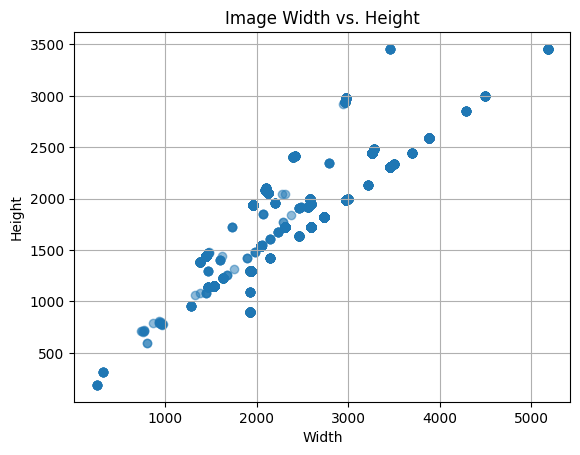

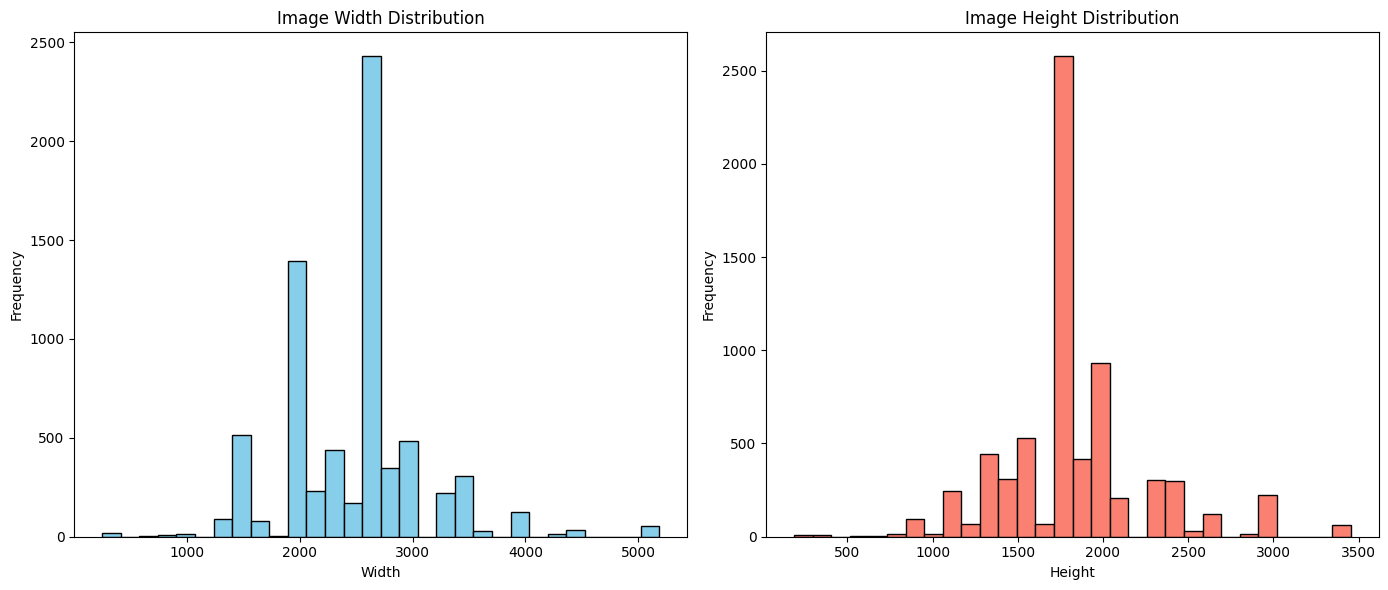

In [34]:
# function that checks the image sizes
def check_image_sizes(dir):
    sizes = []
    for img_file in os.listdir(dir):
        img_path = os.path.join(dir, img_file)
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
        except Exception as e:
            print(f"Error opening {img_file}: {e}")
    return sizes

# check sizes for training and testing data
train_sizes = check_image_sizes(train_dir)
test_sizes = check_image_sizes(test_dir)


# turn sizes into a df
sizes_df = pd.DataFrame(train_sizes, columns=['Width', 'Height'])

# scatterplot of width vs height
plt.scatter(sizes_df['Width'], sizes_df['Height'], alpha=0.5)
plt.title('Image Width vs. Height')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)

plt.figure(figsize=(14, 6))

# width Histogram
plt.subplot(1, 2, 1)
plt.hist(sizes_df['Width'], bins=30, color='skyblue', edgecolor='black')
plt.title('Image Width Distribution')
plt.xlabel('Width')
plt.ylabel('Frequency')

# height Histogram
plt.subplot(1, 2, 2)
plt.hist(sizes_df['Height'], bins=30, color='salmon', edgecolor='black')
plt.title('Image Height Distribution')
plt.xlabel('Height')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In the scatter plot, Dr. Iris sees a clear positive correlation between the width and height of the images with larger images being proportionally scaled. However, the plots also reveal significant variation in image sizes, suggesting a potential inconsistency in image resolution, which was one of the dataset warning in Kaggle.

---

Next Dr. Iris takes calculatwa the **pixel size** and **aspect ratio** of each image. She uses a standard DPI (dots per inch) of 72 to estimate the total pixel count for each image and then computes the aspect ratio as the ratio of width to height.

To visualize these new insights:
1. **Pixel Size Distribution**: A histogram shows how the total pixel count varies across images, highlighting the diversity in image resolution.
2. **Aspect Ratio Distribution**: Another histogram reveals the distribution of aspect ratios, helping Dr. Iris assess whether most images are proportionally similar or if there are significant variations in shape

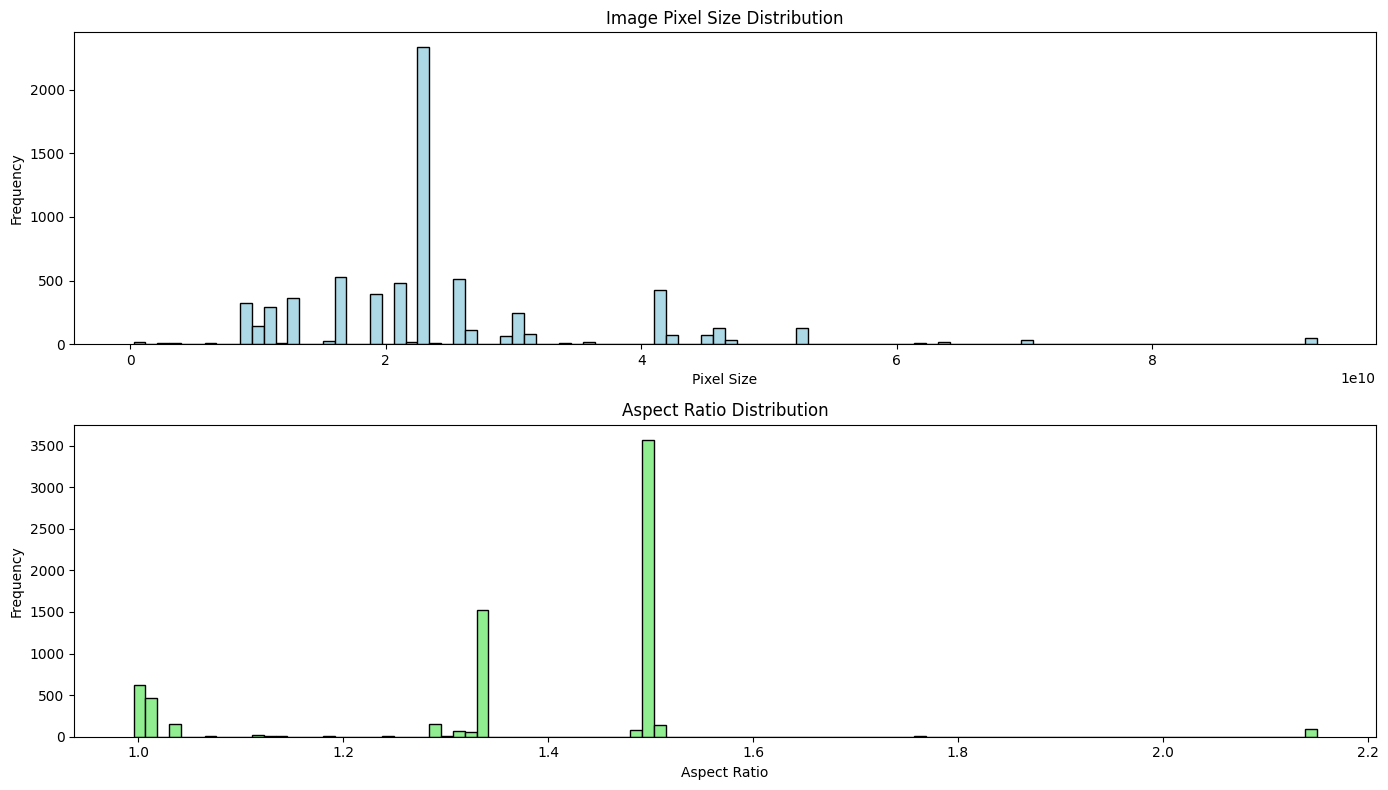

In [35]:
DPI = 72
sizes_df['Pixel_Size'] = (sizes_df['Width'] * DPI) * (sizes_df['Height'] * DPI) # pixel size = (width * dpi) * (height * dpi)
sizes_df['Aspect_Ratio'] = sizes_df['Width'] / sizes_df['Height'] # aspect ratio = width / height

plt.figure(figsize=(14, 8))

# histogram of Pixel Size
plt.subplot(2, 1, 1)
plt.hist(sizes_df['Pixel_Size'], bins=100, color='lightblue', edgecolor='black')
plt.title('Image Pixel Size Distribution')
plt.xlabel('Pixel Size')
plt.ylabel('Frequency')

# histogram of Aspect Ratio
plt.subplot(2, 1, 2)
plt.hist(sizes_df['Aspect_Ratio'], bins=100, color='lightgreen', edgecolor='black')
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Image Pixel Size Distribution:**

From the pixel size distribution, Dr. Iris can see that most of the images gather near a size of approximately 2 × 10^9 pixels. Although there are a few outliers with larger pixel sizes, but these have very little frequency. This implies that while most of the images are fairly uniform in terms of pixel size, there are some that deviate significantly, which she will need to pay attention during preprocessing to avoid inconsistencies in input dimensions for the model.

**Aspect Ratio Distribution:**

From the aspect ratio distribution, Dr. Iris sees that a majority of images have an aspect ratio around 1.5, while only a few skew far from 1.0, which is important because models often perform better when input images have consistent aspect ratios. So she decides to normalize or pad the inconsistent images to bring them into alignment during preprocessing


---



## Resizing

Dr. Iris wants to delete any existing directories before proceeding with testing or creating new ones

In [36]:
# delete any exisiting folders (just for testing)

def delete_dir(dir):
  if os.path.exists(dir):
    shutil.rmtree(dir)
    print(f"Directory {dir} has been deleted.")
  else:
    print(f"Directory {dir} does not exist.")

resized_train_dir = '/content/resized_train_images'

She resizes images to a uniform size of **224x224 pixels**. This will ensurw that all images are standardized, making them consistent for model training

She first clears the resized image directory using the previously created function to delete any existing files and then creates a new directory to store the resized images

In [37]:
def resize_img(image_path, target_size, save_dir):
    with Image.open(image_path) as img:
        resized_img = img.resize(target_size)
        resized_img.save(os.path.join(save_dir, os.path.basename(image_path)))

target_size = (224, 224)
resized_train_dir = '/content/resized_train_images'
delete_dir(resized_train_dir)
os.makedirs(resized_train_dir, exist_ok=True)

for img_file in train_files[:5]: #resize the first five training images
    img_path = os.path.join(train_dir, img_file)
    resize_img(img_path, target_size, resized_train_dir)

Directory /content/resized_train_images does not exist.


Dr. Iris now displays the first 5 resized images and confirms that the resizing process worked correctly. This step helps her confirm that the resizing function is working as intended and that the resized images are ready for further preprocessing or direct use in model training

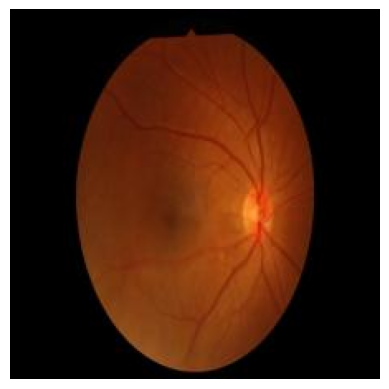

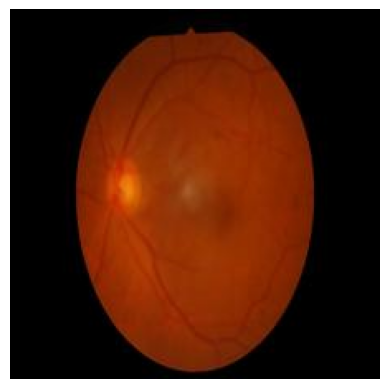

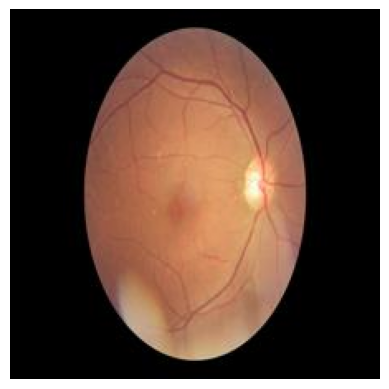

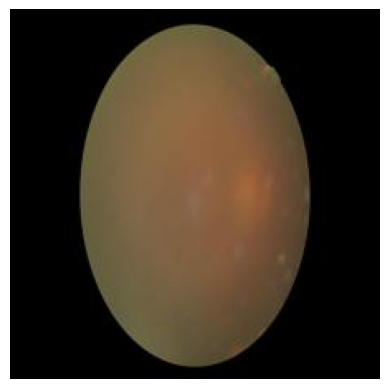

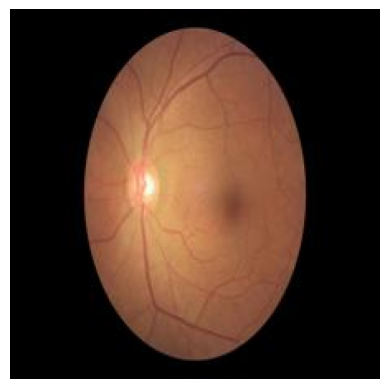

In [38]:
# use inline to for matplotlib to render correctly
%matplotlib inline

resized_train_files = os.listdir(resized_train_dir)

for i in range(5): # display the first five resized training images
    image_path = os.path.join(resized_train_dir, resized_train_files[i])

    try:
        new_img = Image.open(image_path)
        plt.imshow(new_img)
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error opening image {image_path}: {e}")

Dr. Iris sees that the resizing process has been successful, as each image now displays consistently at the target size of **224x224 pixels**

## Image Quality + Sharpening

Dr. Iris uses image-processing techniques like sharpening images and detecting blurred regions using methods such as Laplacian variance

In [39]:
def is_blurry(image_path, threshold):
    with Image.open(image_path) as img:
        img_np = np.array(img.convert('L'))  # convert to grayscale for laplacian
        laplacian_var = Laplacian(img_np, CV_64F).var()
        # print(f"Laplacian variance for {os.path.basename(image_path)}: {laplacian_var}")
        return laplacian_var < threshold

blurry_images = []
blurry_count = 0

for file in resized_train_files:  # resize only the first 5 images for now
    img_path = os.path.join(resized_train_dir, file)
    if is_blurry(img_path, 100): # use threshold of 50 for blurriness
        blurry_images.append(file)
        blurry_count += 1

print("number of blurry images: ", blurry_count)

number of blurry images:  3


Shee sees that out of the first 5 images, some were considered blurry, so Dr. Iris decides to sharpen the images next

She creates a function that uses an **Unsharp Mask** filter to enhance the sharpness. Dr. Iris sets up a new directory, **sharpened_images**, and applies the sharpening filter only to the previously identified blurry images

In [40]:
def sharpen(image_path, save_dir):
    with Image.open(image_path) as img:
        sharpened_img = img.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))
        sharpened_img.save(os.path.join(save_dir, os.path.basename(image_path)))


sharpened_images_dir = "/content/sharpened_images"
delete_dir(sharpened_images_dir)
os.makedirs(sharpened_images_dir, exist_ok=True)


for file in blurry_images: # sharpen only the blurry images
    img_path = os.path.join(resized_train_dir, file)
    sharpen(img_path, sharpened_images_dir)

print(f"Sharpened blurry images saved in {sharpened_images_dir}")


Directory /content/sharpened_images does not exist.
Sharpened blurry images saved in /content/sharpened_images


Dr. Iris visualizes the **sharpened images** by loading and displaying them from the **sharpened_images** directory. Looking at the first few images, she confirms that the sharpening process has been successful

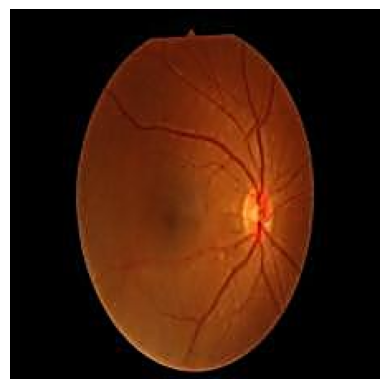

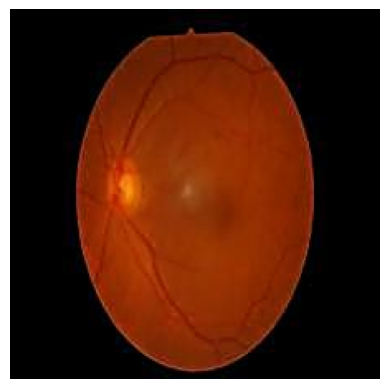

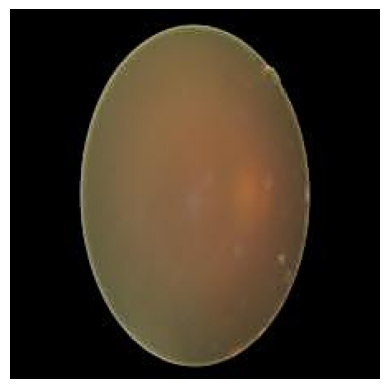

In [41]:
sharpened_train_files = os.listdir(sharpened_images_dir)

for i in range(len(blurry_images)): # display the first five sharpened images
    image_path = os.path.join(sharpened_images_dir, sharpened_train_files[i])

    try:
        new_img = Image.open(image_path)
        plt.imshow(new_img)
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error opening image {image_path}: {e}")

## Normalization

After sharpening blurry images, Dr. Iris adds a **normalization** step to ensure that the pixel values of all images fall within the range **[0, 1]**, which is essential for training most machine learning models.

She creates a new directory, **normalized_images**, where the processed files are saved

In [42]:
def normalize(image_path, save_dir):
    with Image.open(image_path) as img:
        img_np = np.array(img, dtype=np.float32)
        img_normalized = img_np / 255.0  # normalize to [0, 1]

        normalized_img = Image.fromarray(np.uint8(img_normalized * 255))  # re-scale back to [0, 255] to save file
        normalized_img.save(os.path.join(save_dir, os.path.basename(image_path)))

normalized_images_dir = "/content/normalized_images"
delete_dir(normalized_images_dir)
os.makedirs(normalized_images_dir, exist_ok=True)

for file in os.listdir(resized_train_dir): # normalize resized images + sharpened images
    if file in blurry_images:
      img_path = os.path.join(sharpened_images_dir, file)
    else:
      img_path = os.path.join(resized_train_dir, file)

    normalize(img_path, normalized_images_dir)

print(f"All images have been normalized and saved in {normalized_images_dir}.")

Directory /content/normalized_images does not exist.
All images have been normalized and saved in /content/normalized_images.


Dr. Iris now visualizes the first five normalized images and sees  that the normalization process worked alright.

This final check ensures that the normalization has been applied consistently and that the images are ready for use in the upcoming machine learning tasks

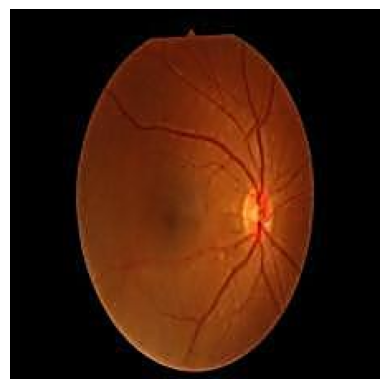

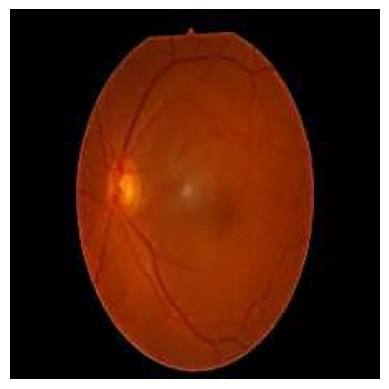

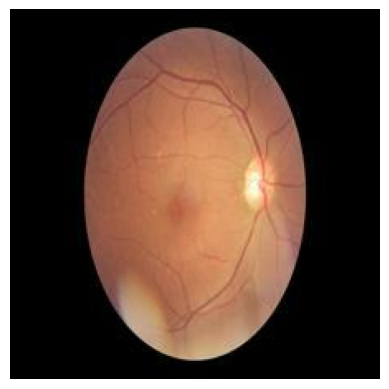

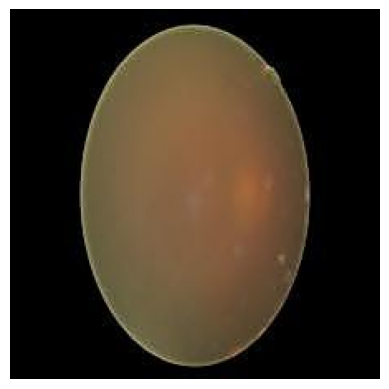

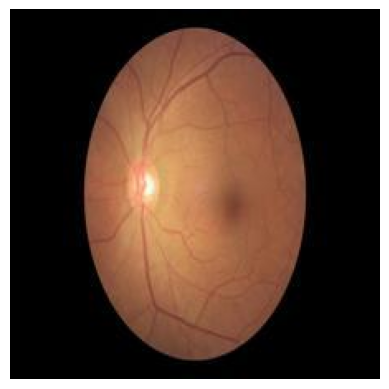

In [43]:
normalized_train_files = os.listdir(normalized_images_dir)

for i in range(5): # display the first five sharpened images
    image_path = os.path.join(normalized_images_dir, normalized_train_files[i])

    try:
        new_img = Image.open(image_path)
        plt.imshow(new_img)
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error opening image {image_path}: {e}")

This concludes the image exploration part, and now Dr. Iris shifts her focus to the next phase: **basic data exploration and summary statistics** of the tabular data. This will include gaining deeper insights into the structure, distribution, and characteristics of the dataset, which will guide her in preparing the data for model building and analysis

# Data Exploration and Summary Statistics

Now that Dr. Iris knows all the main statistics, distributions, and had a rough idea about inner relationship among the features, she starts asking important questions

## Question 1: How does the mean age of patients with each ocular disease compare?

She calculates the mean age for each disease category (e.g., Diabetes, Glaucoma, Cataract) to explore whether certain conditions tend to affect older or younger populations

            Disease   Mean Age
3          Cataract  66.467662
2          Glaucoma  62.418136
6            Myopia  61.476868
4  Age Degeneration  61.227129
7             Other  59.395334
0            Normal  56.857279
1          Diabetes  56.417650
5      Hypertension  56.142857


<ipython-input-44-af8383cd6753>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Disease', y='Mean Age', data=mean_age_df, palette='viridis')


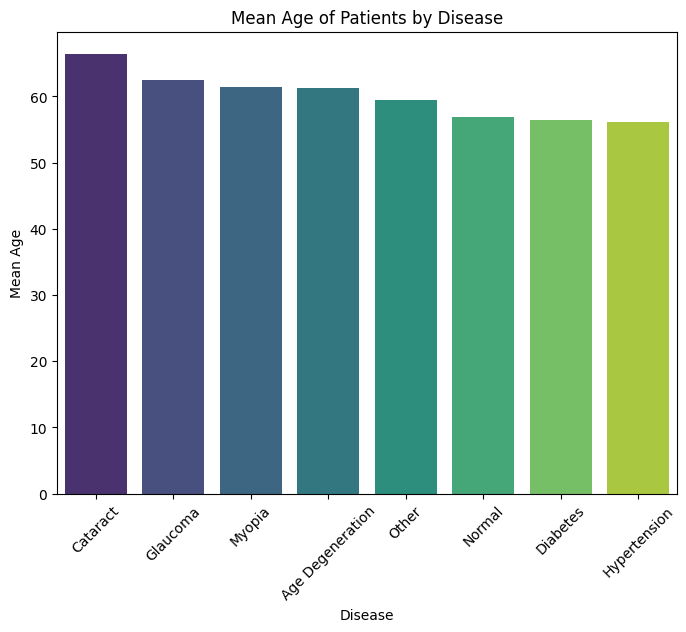

In [44]:
# a dictionary to store mean age per disease
mean_age_per_disease = {}
disease_columns = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']

for disease in disease_columns:
    mean_age_per_disease[disease] = cleaned_df[cleaned_df[disease] == 1]['Patient Age'].mean()

mean_age_df = pd.DataFrame(list(mean_age_per_disease.items()), columns=['Disease', 'Mean Age'])
mean_age_df = mean_age_df.sort_values(by='Mean Age', ascending=False) # sorting by mean age for better comparison
print(mean_age_df)

# visualizing
plt.figure(figsize=(8, 6))
sns.barplot(x='Disease', y='Mean Age', data=mean_age_df, palette='viridis')
plt.title('Mean Age of Patients by Disease')
plt.xlabel('Disease')
plt.ylabel('Mean Age')
plt.xticks(rotation=45)
plt.show()

Dr. Iris discovers the following:

- **Cataract** has the highest mean age at **66.47 years**, followed by **Glaucoma** at **62.42 years**, which indicates that these conditions are more common in older patients
- **Age Degeneration** and **Myopia** also have relatively higher mean ages, around **61 years**
- Patients labeled as **Normal** and those diagnosed with **Diabetes** or **Hypertension** tend to be younger, with mean ages around **56 years**

These findings suggest that there are some age-related conditions like **Cataract** and **Glaucoma**, which are more prevalent in older patients, while **Diabetes** and **Hypertension** affect all populations

## Question 2: Which feature shows the highest variance, and how does that affect modeling?

Dr. Iris wants to analyze the variance of each feature, such as patient age, disease types, and other numerical or categorical variables. Features with high variance indicate a broad range of values, while low variance suggests that most of the data points are clustered around a central value.

Why may this be important?

Because high variance in certain features (e.g., age or a specific disease) could introduce instability into the model, as these features might cause the model to focus disproportionately on rare or extreme cases


Sorted variance (highest to lowest):
Patient Age         121.33
Patient Sex           0.25
Normal                0.22
Diabetes              0.22
Other                 0.19
Glaucoma              0.06
Cataract              0.06
Age Degeneration      0.05
Myopia                0.04
Hypertension          0.03
dtype: object


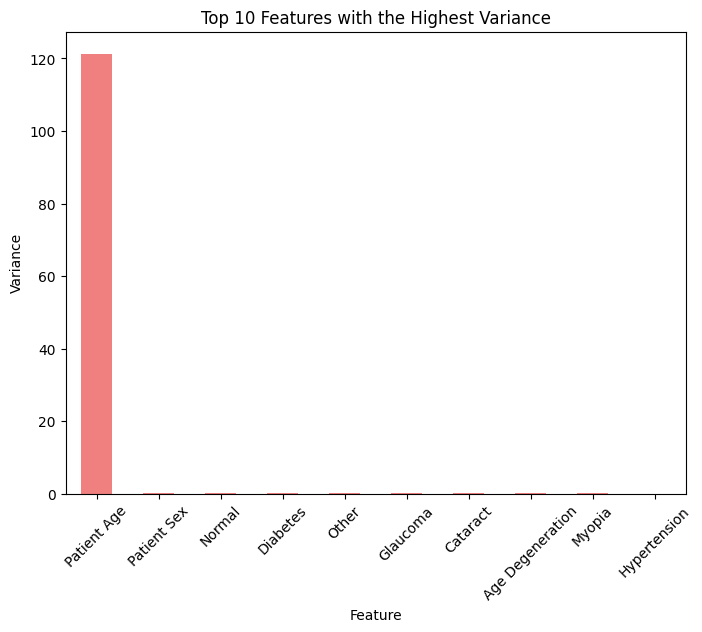

In [45]:
def calculate_variance(df):
    df_numerical = df.drop(columns=['ID'], errors='ignore') # we don't want 'ID' here
    variance_df = df_numerical.var(numeric_only=True)       # variance for numerical features
    variance_df = variance_df.apply(lambda x: f"{x:.2f}")

    sorted_variance_df = variance_df.sort_values(ascending=False)  # soritng the variances in descending order

    print("\nSorted variance (highest to lowest):")
    print(sorted_variance_df)

    plt.figure(figsize=(8, 6)) # plotting
    sorted_variance_df.head(10).astype(float).plot(kind='bar', color='lightcoral')
    plt.title('Top 10 Features with the Highest Variance')
    plt.xlabel('Feature')
    plt.ylabel('Variance')
    plt.xticks(rotation=45)
    plt.show()


calculate_variance(cleaned_df)

Dr. Iris discovers the following:

1. **Patient Age** has the highest variance (121.33), which is way wider than any other feature
2. **Patient Sex** shows a low variance (0.25), which confirms the earlier conclusions that the gender distribution is more balanced, but still has some variation.
3. **Normal**, **Diabetes**, and **Other diseases** show moderate variance (around 0.19 to 0.22), while the less frequent diseases like **Glaucoma**, **Cataract**, and **Hypertension** have very low variance

# Hypothesis Testing


Dr. Iris now turns her attention to hypothesis testing to explore relationships and make statistical inferences from the data. She identifies several hypotheses to test, using different statistical methods

## Null Hypothesis 1: Patients with one disease are more likely to have other diseases

In order to test this hypothesis, Dr. Iris wants to study only those patients, who have 2 or more dieseases at the same time.<br>
She creates a new column indicating the amount of diseases for a patient

In [46]:
cleaned_df['num_diseases'] = cleaned_df.iloc[:, 7:15].sum(axis=1)
multiple_diseases_df = cleaned_df[cleaned_df['num_diseases'] > 1]
multiple_diseases_df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,Normal,Diabetes,Glaucoma,...,Hypertension,Myopia,Other,filepath,labels,target,filename,left-diagnostic-category,right-diagnostic-category,num_diseases
2,2,42,0,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,...,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,[D],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg,moderate,moderate,2
3,4,53,0,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,...,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,[D],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg,none,mild,2
5,6,60,0,6_left.jpg,6_right.jpg,macular epiretinal membrane,moderate non proliferative retinopathy，epireti...,0,1,0,...,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,[D],"[0, 1, 0, 0, 0, 0, 0, 0]",6_right.jpg,none,moderate,2


Now Dr. Iris builds a **comorbidity matrix** to track how often different diseases co-occur in patients with multiple diagnoses. For each patient, she checks which diseases they have and updates the matrix, increasing the count whenever two diseases co-occur.

This matrix will help her understand patterns of disease combinations and identify common comorbidities among ocular conditions

In [47]:
disease_columns = ['Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']
comorbidity_matrix = pd.DataFrame(0, index=disease_columns, columns=disease_columns)

for index, row in multiple_diseases_df.iterrows():
    patient_diseases = row[disease_columns].index[row[disease_columns] > 0]
    for disease1 in patient_diseases:
        for disease2 in patient_diseases:
            if disease1 != disease2:
                comorbidity_matrix.at[disease1, disease2] += 1


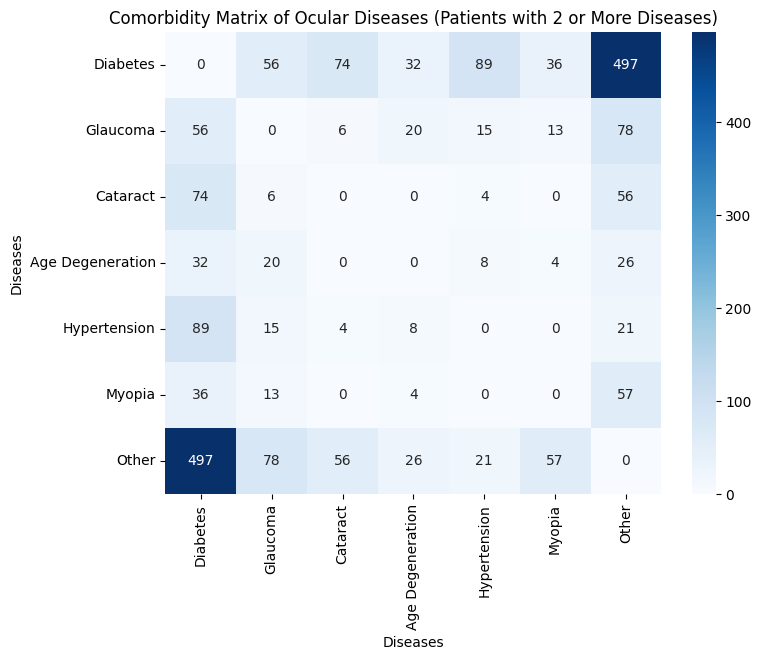

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(comorbidity_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Comorbidity Matrix of Ocular Diseases (Patients with 2 or More Diseases)')
plt.xlabel('Diseases')
plt.ylabel('Diseases')
plt.show()

#### Interpretation

Dr. Iris sees that the diagonal of the comorbidity matrix represents patients with only one disease. Since she is analyzing multiple diseases, the diagonal values are set to zero to focus solely on co-occurring conditions.


She now is interpreting the off-diagonal elements, which show the number of patients with multiple diseases:<br><br>
**Diabetes** (D) has significant overlap with other conditions:<br>
56 patients also have Glaucoma (G).<br>
74 patients also have Cataract (C).<br>
32 patients have Age-related Macular Degeneration (A).<br>
89 patients have Hypertension (H).<br>
36 patients have Pathological Myopia (M).<br>
497 patients have Other diseases/abnormalities (O).<br><br>
**Glaucoma** (G) also shows notable comorbidities, particularly there are :<br>
56 patients who also have Diabetes (D) ,<br>
4 patients who also have Cataract (C),<br>
20 patients who also have Age-related Macular Degeneration (A),
15 patients who also have Hypertension (H),
13 patients who also have Pathlogical Myopi (M),
and 78 patients who have Other diseases (O).<br><br>
**Cataract** (C) has strong associations with Diabetes (74) and Other diseases (56).<br><br>
**Hypertension** (H) is often comorbid with Diabetes (89) and has associations with other diseases.<br><br>
Due to ambiguity of this category, there is no surprise that **Other diseases/abnormalities** (O) show the highest counts overall, especially with Diabetes (497).

----

What may this imply?

Dr. **Iris** makes the following observations from the comorbidity matrix:

1. **Diabetes as a Central Disease**:  
   **Diabetes** frequently co-occurs with other diseases, which suggests that it might be a primary condition in the dataset that leads to additional diagnoses

2. **High Comorbidity with "Other Diseases"**:  
   Several diseases show high comorbidity with the **"Other diseases"** category, which may be an indicator of a variety of conditions grouped here, which needs deeper investigation.

### Next Step: Testing the Hypothesis with a Chi-Square Test
Dr. Iris will now use a **chi-square test** to statistically confirm if the comorbidities she observed are significant. She uses the chi-square test because it is ideal for testing relationships between categorical variables, like the presence or absence of diseases


In [52]:
def perform_chi2_test(multiple_diseases_df):
    results = {}
    total_patients = multiple_diseases_df.shape[0]

    for disease1 in disease_columns:
        for disease2 in disease_columns:
            if disease1 != disease2:
                both_diseases = multiple_diseases_df[
                    (multiple_diseases_df[disease1] > 0) & (multiple_diseases_df[disease2] > 0)
                ].shape[0]

                only_disease1 = multiple_diseases_df[
                    (multiple_diseases_df[disease1] > 0) & (multiple_diseases_df[disease2] == 0)
                ].shape[0]

                only_disease2 = multiple_diseases_df[
                    (multiple_diseases_df[disease2] > 0) & (multiple_diseases_df[disease1] == 0)
                ].shape[0]

                neither_disease = total_patients - (both_diseases + only_disease1 + only_disease2)

                contingency_table = [
                    [both_diseases, only_disease2],
                    [only_disease1, neither_disease]
                ]


                if any(count < 0 for count in contingency_table[0]) or any(count < 0 for count in contingency_table[1]):
                    continue
                if any(value == 0 for row in contingency_table for value in row):
                    continue

                chi2, p, _, _ = chi2_contingency(contingency_table)
                results[(disease1, disease2)] = p

    return results


chi2_results = perform_chi2_test(multiple_diseases_df)
significant_results = {k: v for k, v in chi2_results.items() if v > 0.05}

non_symmetrical_results = []
seen_pairs = set()

for (disease1, disease2), p_value in significant_results.items():
  pair = tuple(sorted((disease1, disease2)))
  if pair not in seen_pairs:
    non_symmetrical_results.append((disease1, disease2))
    seen_pairs.add(pair)

for diseases in non_symmetrical_results:
    p_value = significant_results[diseases]
    if p_value > 0.05:
        print(f"There is significant association found between {diseases}, p-value is {p_value:.2f}")

There is significant association found between ('Diabetes', 'Hypertension'), p-value is 0.07
There is significant association found between ('Glaucoma', 'Age Degeneration'), p-value is 0.09
There is significant association found between ('Glaucoma', 'Hypertension'), p-value is 0.12
There is significant association found between ('Glaucoma', 'Myopia'), p-value is 0.42
There is significant association found between ('Age Degeneration', 'Hypertension'), p-value is 0.38
There is significant association found between ('Age Degeneration', 'Myopia'), p-value is 0.14



### Chi-square test results interpretation:

1. **Diabetes and Hypertension**:  
   With a p-value of **0.07159**, there is a **significant association** between **Diabetes** and **Hypertension**. This suggests that these two conditions tend to co-occur in the dataset, even though the p-value is slightly above the conventional threshold of 0.05

2. **Glaucoma and Age Degeneration**:  
   The p-value of **0.09442** indicates a **significant association** between **Glaucoma** and **Age Degeneration**, showing that these two conditions often occur together

3. **Glaucoma and Hypertension**:  
   With a p-value of **0.12257**, there is a **significant association** between **Glaucoma** and **Hypertension**, suggesting that these conditions may co-occur more frequently than by chance

4. **Glaucoma and Myopia**:  
   The p-value of **0.41869** indicates a **significant association** between **Glaucoma** and **Myopia**. This shows that these conditions tend to co-occur in this dataset

5. **Age Degeneration and Hypertension**:  
   A p-value of **0.37586** shows a **significant association** between **Age Degeneration** and **Hypertension**, meaning they frequently co-occur in the dataset

6. **Age Degeneration and Myopia**:  
   With a p-value of **0.13718**, there is a **significant association** between **Age Degeneration** and **Myopia**, suggesting that these conditions also tend to co-occur

All these pairs of conditions tend to co-occur more frequently than by random chance, which indicates possible comorbidity patterns between them

Dr. Iris now creates a heatmap to visualize the p-values from the chi-square test to different conditions

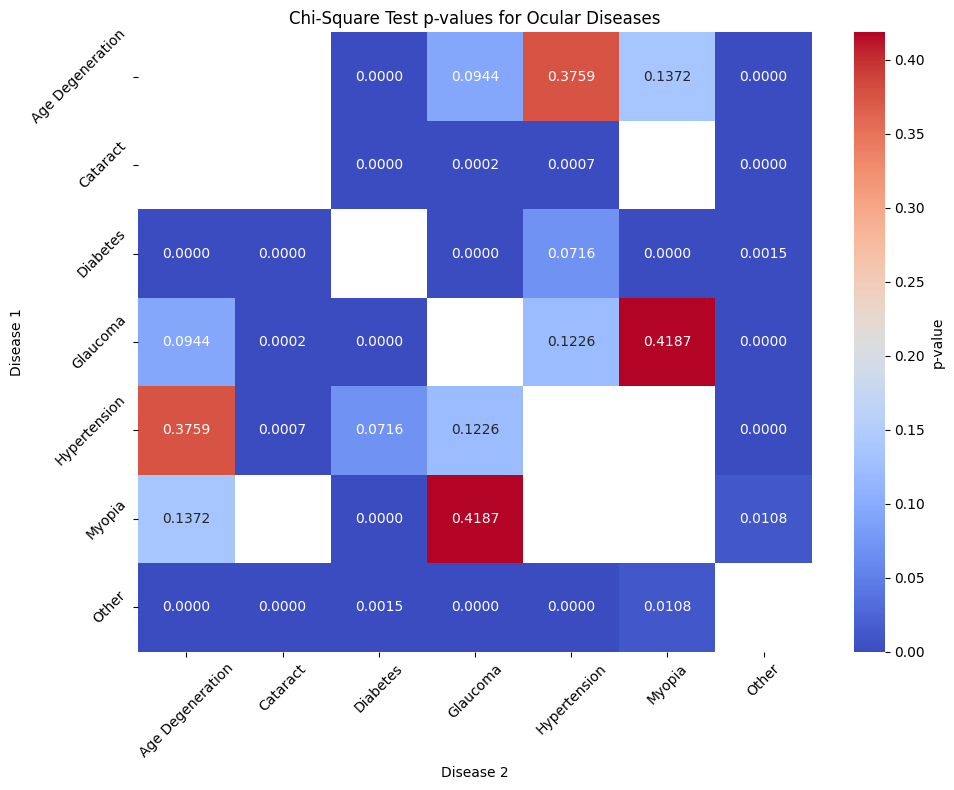

In [53]:
results_df = pd.DataFrame.from_dict(chi2_results, orient='index', columns=['p-value'])
results_df.index = pd.MultiIndex.from_tuples(results_df.index, names=['Disease 1', 'Disease 2'])
results_df = results_df.reset_index()

heatmap_data = results_df.pivot(index="Disease 1", columns="Disease 2", values="p-value")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title('Chi-Square Test p-values for Ocular Diseases')
plt.xlabel('Disease 2')
plt.ylabel('Disease 1')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show();

### Hypothesis 1 Conclusions:

0. **We fail to reject the null hypothesis for some pairs of conditions**:  
   Dr. Iris finds that for certain disease pairs, patients with one condition tend to have the other as well, indicating significant comorbidities

1. **Risk Factors**:  
   Dr. Iris observes a strong association between **Diabetes** and other ocular conditions. This suggests that patients with Diabetes are at a higher risk of developing additional issues like **Glaucoma** and **Cataracts**. She recognizes the need for **close monitoring** of diabetic patients to detect these conditions early

2. **Patient Management**:  
   Dr. Iris understands that identifying these comorbidities is essential for an **integrated care approach**. By considering multiple conditions together, she can improve the **treatment and management** plans for patients with multiple diagnoses

3. **Further Research**:  
   Dr. Iris notices that a large number of patients are categorized under **"Other diseases"**. She sees the potential for further investigation into these conditions to better understand their role in ocular health and the impact of their co-occurrence with more common conditions

## Null Hypothesis 2: There's no significant age difference between patients with and without diabetes

So, Dr. Iris observes that **Diabetes** is the most common condition among the diseases in her dataset. To investigate whether **Diabetes is associated with age**, she formulates a hypothesis to determine if there is a significant difference in the average age between patients with and without diabetes.

She uses a **t-test**, which is well-suited for comparing the means of **two independent groups**—in this case, the ages of patients with and without diabetes. Since age is a **continuous variable** and diabetes presence creates two distinct groups, the t-test will help Dr. Iris identify whether any observed age differences are statistically significant or just due to random variation

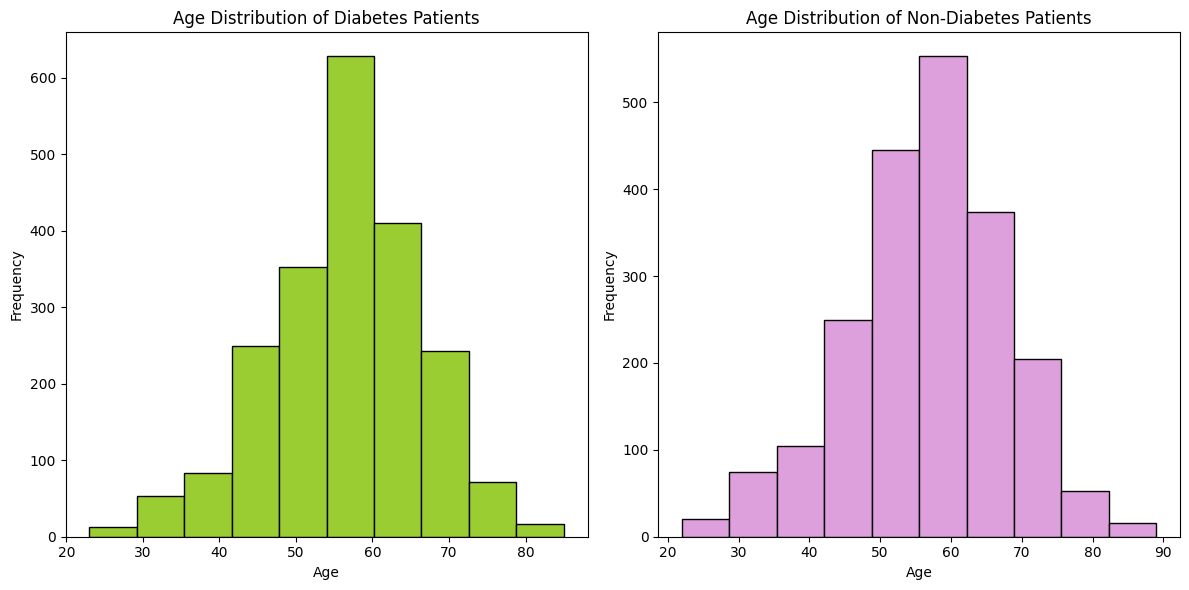

In [54]:
diabetes_age = cleaned_df[cleaned_df['Diabetes'] == 1]['Patient Age']
non_diabetes_age = cleaned_df[cleaned_df['Normal'] == 1]['Patient Age']  # Using 'N' for normal fundus

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(diabetes_age, bins=10, color="yellowgreen", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution of Diabetes Patients")

plt.subplot(1, 2, 2)
plt.hist(non_diabetes_age, bins=10, color="plum", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution of Non-Diabetes Patients")

plt.tight_layout()
plt.show()

Hypothesis 1 Results:
T-statistic:  -1.3579535437826737
P-value:  0.17455116316550867


<ipython-input-55-3207788bc4be>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes', y='Patient Age', data=cleaned_df, palette=colors)


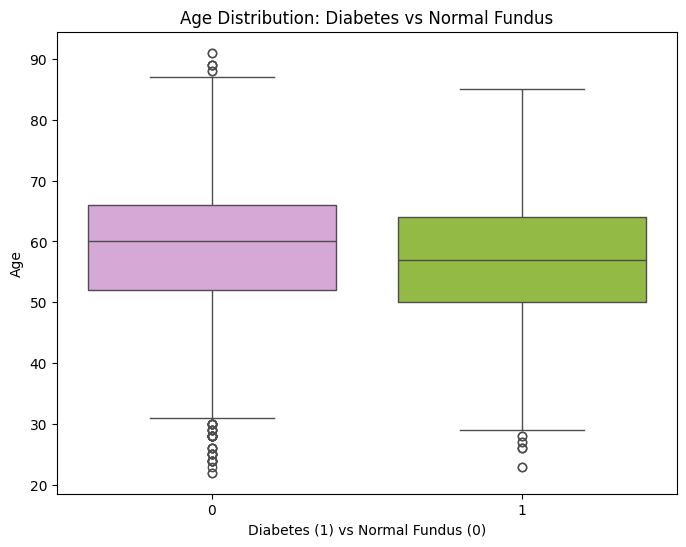

In [55]:
t_stat, p_value = stats.ttest_ind(diabetes_age, non_diabetes_age)
print("Hypothesis 1 Results:")
print("T-statistic: ", t_stat)
print("P-value: ",p_value)

plt.figure(figsize=(8, 6))
colors = ['plum', 'yellowgreen']
sns.boxplot(x='Diabetes', y='Patient Age', data=cleaned_df, palette=colors)
plt.title('Age Distribution: Diabetes vs Normal Fundus')
plt.xlabel('Diabetes (1) vs Normal Fundus (0)')
plt.ylabel('Age')
plt.show()

### Hypothesis 2 Conclusions:

- **T-statistic**: -1.36
- **P-value**: 0.17455

1. **T-statistic**: The negative t-statistic suggests that the average age of patients with diabetes might be slightly lower than those without diabetes, but the difference is minimal

2. **P-value**: With a p-value of **0.17455**, which is **greater than the 0.05 significance threshold**, Dr. Iris **fails to reject the null hypothesis**. This means there is **no statistically significant difference** in the average age between patients with and without diabetes

The t-test results suggest that **age does not significantly differ** between those with and without diabetes. Therefore, **diabetes does not appear to be strongly associated with age** in this dataset, meaning that any age differences between the groups are likely due to random variation rather than an effect of diabetes

## Null Hypothesis 3: There's no correlation between age and the number of ocular diseases

Dr. Iris now explores the relationship between a patient's **age** and the **number of ocular diseases** they have. Using **Pearson correlation**, she tests the **linear relationship** between these two continuous variables

This analysis helps her understand if older patients are more likely to have multiple eye conditions. The Pearson correlation provides a **quantitative measure** of the relationship, along with a **statistical significance** test to determine if the result is meaningful or due to chance


Hypothesis 2 Results:
Correlation coefficient:  0.09720903965632197
P-value:  8.126144414985553e-15


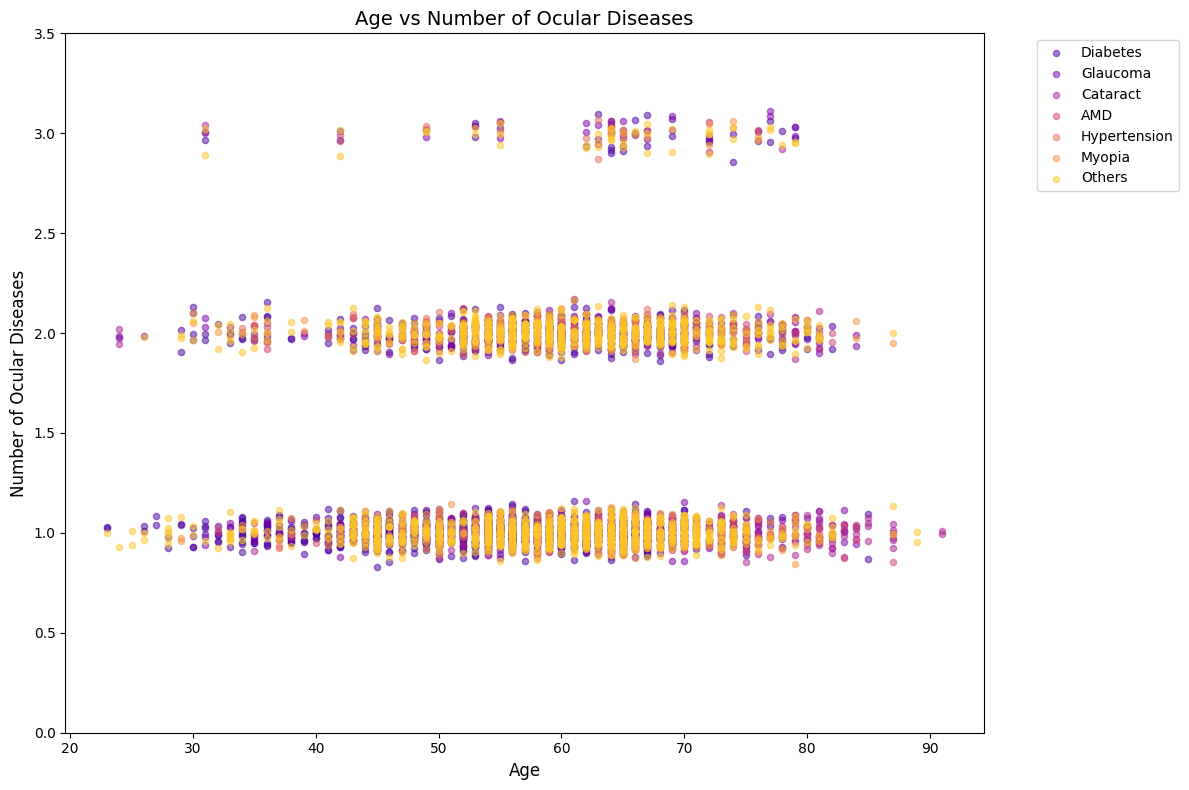

In [56]:
diseases = ['Diabetes', 'Glaucoma', 'Cataract', 'Age Degeneration', 'Hypertension', 'Myopia', 'Other']
disease_names = ['Diabetes', 'Glaucoma', 'Cataract', 'AMD', 'Hypertension', 'Myopia', 'Others']

cleaned_df['Total Diseases'] = cleaned_df[diseases].sum(axis=1)
correlation, p_value = stats.pearsonr(cleaned_df['Patient Age'], cleaned_df['Total Diseases'])
print("\nHypothesis 2 Results:")
print("Correlation coefficient: ", correlation)
print(f"P-value: ", p_value)

color_palette = sns.color_palette("plasma", len(diseases))
color_map = dict(zip(diseases, color_palette))

plt.figure(figsize=(12, 8))
for disease in diseases:
    disease_df = cleaned_df[cleaned_df[disease] == 1]
    y_jitter = np.random.normal(0, 0.05, len(disease_df))
    plt.scatter(disease_df['Patient Age'], disease_df['Total Diseases'] + y_jitter,
                label=disease, color=color_map[disease], alpha=0.5, s=20)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Ocular Diseases', fontsize=12)
plt.title('Age vs Number of Ocular Diseases', fontsize=14)
plt.legend(labels=disease_names, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, cleaned_df['Total Diseases'].max() + 0.5)
plt.tight_layout()
plt.show()

### Hypothesis 3 Conclusions:
1. A very slight but positive correlation is indicated by the correlation coefficient of 0.097209. Since the p-value is so tiny in relation to the significance level (0.05 or 0.1), we reject the null hypothesis
2. The number of ocular diseases and age have a statistically significant correlation. Given that there is a slight tendency for the number to increase with age, this relationship is positive
3. The coefficient, however, is weak, indicating that a person's age is not a reliable indicator of how many ocular diseases they may have. For a more thorough understanding of the occurrence of ocular diseases, more research into other variables and potentially non-linear relationships would be helpful


---

Dr. Iris recognizes that while **age** is a key factor in ocular health, **gender** may also influence the prevalence of eye conditions. To explore this, she visualizes the **distribution of genders** across various ocular diseases to see if certain conditions are more common in one gender than the other

By analyzing the **gender breakdown** for each disease, Dr. Iris aims to identify potential patterns and trends, helping her understand whether men or women are more likely to be affected by specific eye conditions


<Figure size 1000x800 with 0 Axes>

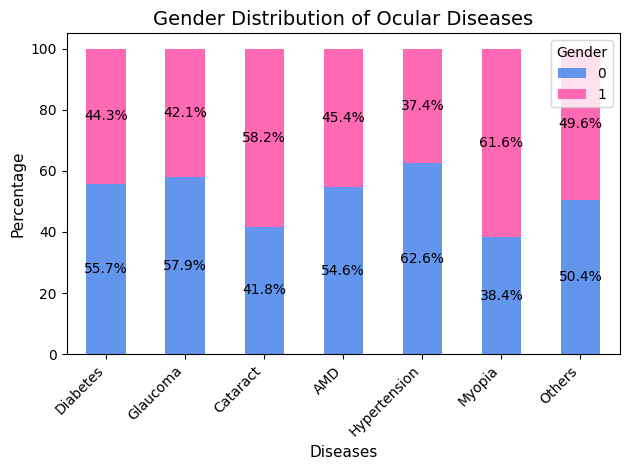

Counts:
                     0    1
Diabetes          1181  938
Glaucoma           230  167
Cataract           168  234
Age Degeneration   173  144
Hypertension       127   76
Myopia             108  173
Other              799  787

Percentages:
                          0          1
Diabetes          55.733837  44.266163
Glaucoma          57.934509  42.065491
Cataract          41.791045  58.208955
Age Degeneration  54.574132  45.425868
Hypertension      62.561576  37.438424
Myopia            38.434164  61.565836
Other             50.378310  49.621690


In [57]:
gender_counts = {disease: [] for disease in diseases}
for disease in diseases:
    male_count = cleaned_df[(cleaned_df[disease] == 1) & (cleaned_df['Patient Sex'] == 0)].shape[0]
    female_count = cleaned_df[(cleaned_df[disease] == 1) & (cleaned_df['Patient Sex'] == 1)].shape[0]
    gender_counts[disease] = [male_count, female_count]
gender_df = pd.DataFrame(gender_counts, index=[0, 1]).T
gender_df_percentage = gender_df.div(gender_df.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 8))
color_map = {0: 'cornflowerblue', 1: 'hotpink'}
ax = gender_df_percentage.plot(kind='bar', stacked=True, color=[color_map[0], color_map[1]])
plt.title('Gender Distribution of Ocular Diseases', fontsize=14)
plt.xlabel('Diseases', fontsize=11)
plt.ylabel('Percentage', fontsize=11)
plt.legend(title='Gender', loc='upper right')
plt.xticks(range(len(diseases)), disease_names, rotation=45, ha='right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')
plt.tight_layout()
plt.show()

print("Counts:")
print(gender_df)
print("\nPercentages:")
print(gender_df_percentage)

Dr. Iris notices that the prior analysis does not clearly indicate which gender is more likely to suffer from any specific ocular disease. Given existing research that suggests certain types of **glaucoma**, like **angle-closure glaucoma**, are more common in women, she decides to focus on **glaucoma** to investigate this further

Her goal is to determine if **women are more likely to have glaucoma** in her dataset, aligning with findings from other studies

## Null Hypothesis 4: There is no significant association between gender and the incidence of glaucoma

Dr. Iris chooses to use a **chi-squared test** for this analysis because it is well-suited for her **categorical data** (gender and glaucoma status)

This test provides a **clear and interpretable result**, ideal for medical research, where **statistical accuracy** is crucial

Glaucoma        0    1
Patient Sex           
0            3188  230
1            2769  167

Hypothesis 3 Results:
Chi-square statistic:  2.747224564278787
P-value:  0.09742340676309791


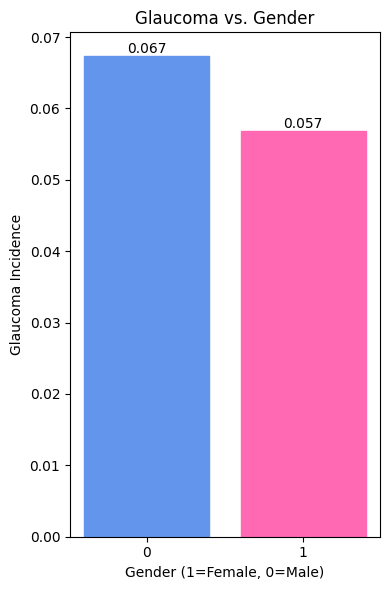

In [58]:
gender_glaucoma = pd.crosstab(cleaned_df['Patient Sex'], cleaned_df['Glaucoma'])
print(gender_glaucoma)
chi2, p_value, dof, expected = stats.chi2_contingency(gender_glaucoma)

print("\nHypothesis 3 Results:")
print("Chi-square statistic: ", chi2)
print("P-value: ", p_value)
grouped_data = cleaned_df.groupby('Patient Sex')['Glaucoma'].mean().reset_index()
plt.figure(figsize=(4, 6))
color_map = {0: 'cornflowerblue', 1: 'hotpink'}
bars = plt.bar(grouped_data['Patient Sex'], grouped_data['Glaucoma'])
for bar, gender in zip(bars, grouped_data['Patient Sex']):
    bar.set_color(color_map[gender])
plt.title('Glaucoma vs. Gender')
plt.xlabel('Gender (1=Female, 0=Male)')
plt.ylabel('Glaucoma Incidence')
plt.xticks(df['Patient Sex'].unique())

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Hypothesis 4 Conclusions:

1. **Insufficient Evidence**:  
   The **p-value** of **0.097423** is higher than the typical **0.05** significance level, meaning there is **insufficient evidence** to confidently conclude that the incidence of **glaucoma** differs significantly between males and females. As a result, Dr. Iris **fails to reject the null hypothesis**

2. **Closer at 0.1 Significance Level**:  
   If a **0.1** significance level were used, the **p-value** is almost equal to the threshold, suggesting that the relationship between **gender and glaucoma** might be worth exploring further, possibly in larger or more focused studies

3. **Significance Level Choice**:  
   This highlights the importance of carefully selecting the **appropriate significance level**. The choice of threshold can directly impact the interpretation of results and, consequently, the reliability of the statistical analysis

Dr. Iris recognizes the need for further research to investigate the potential gender differences in glaucoma incidence more robustly

# Overall EDA Conclusion:

During her EDA, Dr. Iris's had several key findings, which included:

1. **Age as a Factor**:  
   A weak but significant positive correlation was found between **age** and the number of ocular diseases. Older patients are slightly more likely to have multiple conditions, but age alone is not a strong predictor of disease prevalence. This suggests the need to investigate other factors alongside age to understand ocular disease development better

2. **Diabetes and Comorbidities**:  
   **Diabetes** was identified as a primary condition frequently co-occurring with other diseases such as **hypertension** and **Cataracts**. This highlights the importance of close monitoring for diabetic patients, who are at higher risk for multiple ocular diseases

3. **Gender and Glaucoma**:  
   Although the chi-square test showed no significant difference in glaucoma incidence between males and females at the 0.05 level, the results were close to significance at the **0.1 level**. This suggests that gender-related differences in glaucoma prevalence may exist and warrant further investigation in larger or more controlled studies

4. **Comorbidity Patterns**:  
   The **comorbidity matrix** revealed significant associations between several ocular diseases, indicating that many conditions tend to co-occur. This emphasizes the need for **integrated care** approaches, particularly for patients with multiple diagnoses


EDA uncoveres important trends in the dataset and provides a foundation for deeper analysis and future studies. Here, while **age** and **diabetes** emerged as key factors, further research into **gender differences** and other variables is necessary to fully understand ocular disease prevalence. This EDA sets the stage for more focused modeling and clinical applications

# Primary Machine Learning Analysis

During her work, Dr. Iris found that the categories "N D G C A H M O" cause issues as there would be some values were positive for both normal and disease eyes, but there would be no specification on which eye the disease was on. The issue with this is that the files and diagnosis are orientation specific and the row of data contains both eyes information. If Dr. Iris uses the categories exclusively, she runs into the problem later since pulling specific eye orientation data becomes impossible since it is lost in the encoded categories.
Therefore, Dr. Iris choses to exclude those categories for this project.


In [59]:
df2 = df.iloc[:, 1:7]
df2.head()

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords
0,69,1,0_left.jpg,0_right.jpg,cataract,normal fundus
1,57,0,1_left.jpg,1_right.jpg,normal fundus,normal fundus
2,42,0,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy
3,53,0,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy
4,50,1,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy


## Dark Mysteries: Preparing the Cataract Eyes

Dr. Iris starts by extracting the Left-Diagnosis for the 'cataract' keyword. She will also do the same for the Right-Diagnosis.

In [60]:
# Left diagnosis with 'cataract' disease

df2[df2['Left-Diagnostic Keywords'].str.match('cataract')].head()

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords
0,69,1,0_left.jpg,0_right.jpg,cataract,normal fundus
86,55,1,103_left.jpg,103_right.jpg,cataract,normal fundus
100,59,0,119_left.jpg,119_right.jpg,cataract,drusen
218,60,1,254_left.jpg,254_right.jpg,cataract,macular epiretinal membrane
256,69,1,294_left.jpg,294_right.jpg,cataract,normal fundus


In [61]:
# lets put the left cararact data into its own dataframe and see the number of rows it has

df2_left = df2[df2['Left-Diagnostic Keywords'].str.match('cataract')]
print(len(df2_left))

294


Dr. Iris found 294 instances of left eyes with cataract. Now, let's see how many right eyes suffer from this condition.

In [62]:
# Right diagnosis with 'cataract' disease

df2[df2['Right-Diagnostic Keywords'].str.match('cataract')].head()

,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords
20,75,1,24_left.jpg,24_right.jpg,normal fundus,cataract
93,57,1,112_left.jpg,112_right.jpg,normal fundus,cataract
160,55,1,188_left.jpg,188_right.jpg,laser spot，severe proliferative diabetic retin...,cataract
186,36,1,218_left.jpg,218_right.jpg,refractive media opacity,cataract
309,65,0,354_left.jpg,354_right.jpg,normal fundus,cataract


In [63]:
# lets put the right cararact data into its own dataframe and see the number of rows it has

df2_right = df2[df2['Right-Diagnostic Keywords'].str.match('cataract')]
print(len(df2_right))

278


Similarly, 278 instances for right eyes with catarcat. Let's combine them together in a special "cataract" dataset:

In [64]:
# combine the left and right cataract data toghether

df_cat_all = pd.concat([df2_left['Left-Fundus'], df2_right['Right-Fundus']], ignore_index=True)
df_cat_all.head()

,0
0,0_left.jpg
1,103_left.jpg
2,119_left.jpg
3,254_left.jpg
4,294_left.jpg


In [65]:
# lets see how much data for cataract eyes we are working with

len(df_cat_all)

572

So, Dr. Iris observed 572 cataract fundus images. This number will be important later when she willl compare it to the amount of data for normal eyes.

## Image Preparation for Cataract

Let's begin by seeing a random image to see what we are working with

(512, 512, 3)
2120_right.jpg


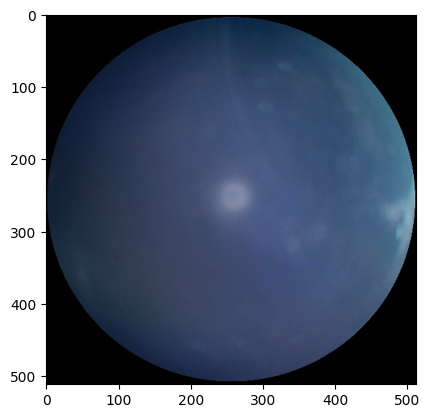

In [66]:
# lets view a random example image
img = df_cat_all[342]
image = cv2.imread(os.path.join(image_dir, img))
plt.imshow(image)
print(image.shape)
print(img)

To achive better understanding of what cataracts look like, Dr. Iris creates a comparative grid showcasing images from our cataract dataset. By visualizing these examples side by side, she can observe common patterns and features associated with cataract-affected eyes. Additionally, the images will be converted to a realistic RGB color palette, enhancing their visual clarity and making them more representative of real-world conditions.

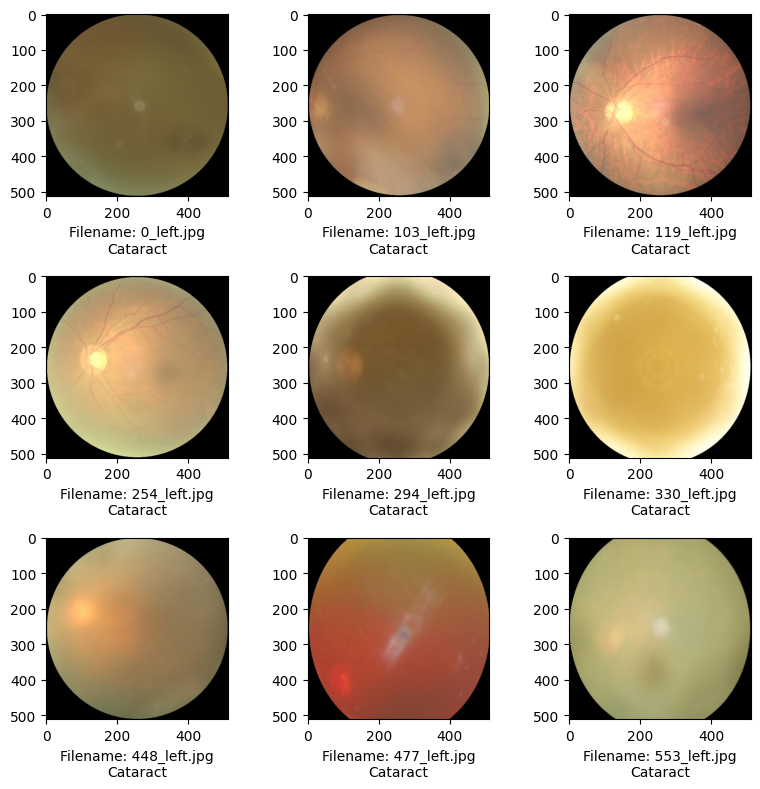

In [67]:
plt.figure(figsize=(8,8))
for i in range(9):
    img = df_cat_all[i]
    image = cv2.imread(os.path.join(image_dir, img))

    ## convert image to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ## subplot variables - (# of rows, # of columns, iterate through locations on grid)
    plt.subplot(3,3,i+1)
    plt.imshow(image_rgb)

    ## label with filename and diagnosis
    plt.xlabel('Filename: {}\n''Cataract'.format(df_cat_all[i]))

plt.tight_layout()

## Data Preperation for Normal Eyes

Next, Dr. Iris will gather a set of normal eye images for our analysis. While she previously reviewed the count of available normal images, it is important to revisit this to ensure completeness. Since she is working with data from both eyes, Dr. Iris must account for discrepancies where some encoded columns lack data for one eye, potentially leaving gaps in the full picture. To address this, she will rely on the labeling in the 'keywords' column as the primary source of truth, as it provides a comprehensive perspective by considering both eyes together.

In [68]:
# create a new dataframe for normal eyes in the left eye and print out the number of rows

df_left_norm = df2[df2['Left-Diagnostic Keywords'].str.match('normal')]
print(len(df_left_norm))

2855


In [69]:
# create a new dataframe for normal eyes in the right eye and print out the number of rows

df_rt_norm = df2[df2['Right-Diagnostic Keywords'].str.match('normal')]
print(len(df_rt_norm))

2735


In [70]:
# combine dataframes into one

df_norm_all = pd.concat([df_left_norm['Left-Fundus'], df_rt_norm['Right-Fundus']], ignore_index=True)
df_norm_all


,0
0,1_left.jpg
1,8_left.jpg
2,9_left.jpg
3,14_left.jpg
4,15_left.jpg
...,...
5585,4642_right.jpg
5586,4644_right.jpg
5587,4660_right.jpg
5588,4671_right.jpg


In total, Dr. Iris have over 5,000 images classified as 'normal,' including both left and right eye images. This is significantly more than the 572 images available in the 'cataract' category. To maintain balance in our dataset and ensure fair model training, she will randomly select an equal number of 572 'normal' images to match the size of the cataract dataset.

In [71]:
# pick 572 normal eye images to match the number of cataract images we pulled

df_norm_random = df_norm_all.sample(n = 572)
df_norm_random.head()

,0
1929,2572_left.jpg
2907,253_right.jpg
2531,3229_left.jpg
5250,3167_right.jpg
1608,1010_left.jpg


In [72]:
# reset the index

df_norm_random = df_norm_random.reset_index(drop=True)
df_norm_random

,0
0,2572_left.jpg
1,253_right.jpg
2,3229_left.jpg
3,3167_right.jpg
4,1010_left.jpg
...,...
567,2749_left.jpg
568,3075_right.jpg
569,740_left.jpg
570,2588_left.jpg


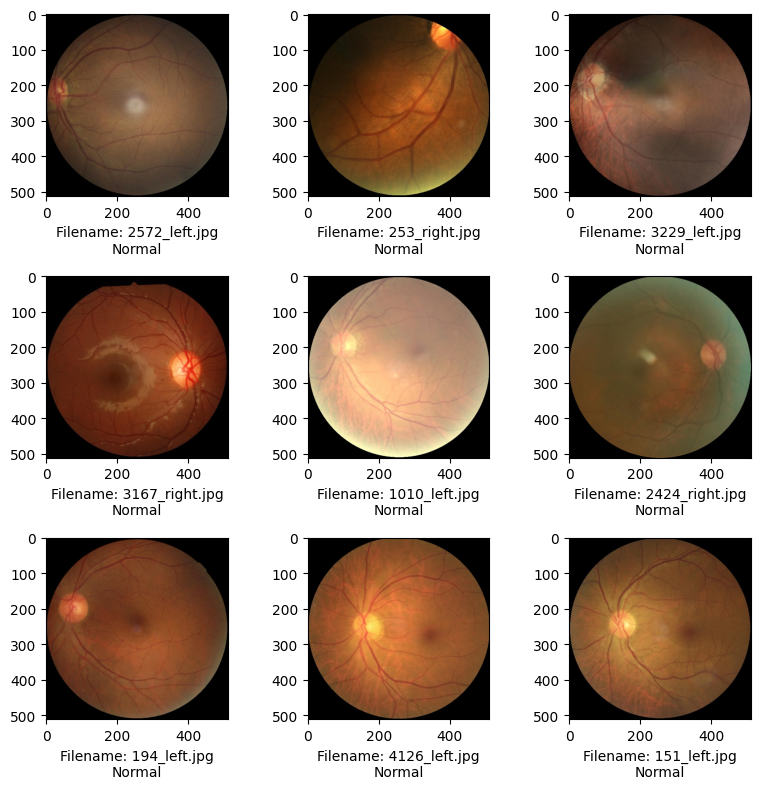

In [73]:
# create a grid for normal eyes

plt.figure(figsize=(8,8))
for i in range(9):
    img = df_norm_random[i]
    image = cv2.imread(os.path.join(image_dir, img))

    ## convert image to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ## subplot variables - (# of rows, # of columns, iterate through locations on grid)
    plt.subplot(3,3,i+1)
    plt.imshow(image_rgb)

    ## label with filename and diagnosis
    plt.xlabel('Filename: {}\n''Normal'.format(df_norm_random[i]))

plt.tight_layout()

## Model Preparation

To prepare the data for modeling, Dr. Iris needs to add category labels to the image lists. Previously, the objects df_norm_random and df_cat_all were converted into lists after appending columns. For convenience and further processing, she will convert these lists back into DataFrames.

Each image will be labeled as either 'normal' or 'cataract.' Since it was planned to use an image data generator for training, which will handle one-hot encoding automatically, she can preserve the original string labels ('normal' and 'cataract') for better readability and interpretation.

In [74]:
df_cat_all = pd.DataFrame(df_cat_all, columns = ["filename"])

# add a new column of '1' to the dataframe
df_cat_all["label"] = "cataract"

df_cat_all.head()

,filename,label
0,0_left.jpg,cataract
1,103_left.jpg,cataract
2,119_left.jpg,cataract
3,254_left.jpg,cataract
4,294_left.jpg,cataract


In [75]:
df_norm_random = pd.DataFrame(df_norm_random, columns = ["filename"])

# add a new column of '1' to the dataframe
df_norm_random["label"] = "normal"

df_norm_random.head()

,filename,label
0,2572_left.jpg,normal
1,253_right.jpg,normal
2,3229_left.jpg,normal
3,3167_right.jpg,normal
4,1010_left.jpg,normal


In [76]:
# now that we have both cataract and normal data, lets combine them into a single dataframe

#df_combined = pd.concat([df_cat_filenames, df_norm_filenames_random], ignore_index=True)
df_combined = pd.concat([df_cat_all, df_norm_random], ignore_index=True)
df_combined

,filename,label
0,0_left.jpg,cataract
1,103_left.jpg,cataract
2,119_left.jpg,cataract
3,254_left.jpg,cataract
4,294_left.jpg,cataract
...,...,...
1139,2749_left.jpg,normal
1140,3075_right.jpg,normal
1141,740_left.jpg,normal
1142,2588_left.jpg,normal


Before feeding the organized set of cataract and normal images into the model, Dr. Iris needs to randomize the rows to ensure that training samples are selected randomly, promoting better generalization during model training.

When combining the datasets, appending them would result in the retention of the old index values, which will create an additional column that Dr. Iris does not need. To avoid this, she will drop the old index entirely and allow the new DataFrame to generate a fresh, sequential index, ensuring a clean and randomized dataset for training.

In [77]:
# randomize rows of combined dataset for training

df_combined_random = df_combined.sample(frac=1).reset_index(drop=True)
df_combined_random

,filename,label
0,2118_right.jpg,cataract
1,3385_right.jpg,normal
2,2683_left.jpg,normal
3,2786_left.jpg,normal
4,2135_left.jpg,cataract
...,...,...
1139,2978_left.jpg,normal
1140,2971_left.jpg,normal
1141,2176_left.jpg,cataract
1142,2158_left.jpg,cataract


In [78]:
# pull 80% of the combined dataset and reserve it for the training data
# the data generator will automatically create a validation set for us later

df_train = df_combined_random.sample(frac=0.8,random_state=42)
df_train.reset_index(drop=True)

# exclude the 80% that was already chosen, while the remaining 20% will go into testing
df_test = df_combined_random.drop(df_train.index)
df_test.reset_index(drop=True)

print(len(df_combined_random))
print(len(df_train))
print(len(df_test))

1144
915
229


## Keras Preprocessing with Image Generator

Let's begin model training using Keras, a powerful deep learning framework that simplifies building, training, and deploying neural network models. With its user-friendly interface, Keras allows Dr.Iris to easily integrate CNNs, which are highly effective for image classification tasks.

She has prepared a well-structured dataframe, and with Keras's flow_from_dataframe functionality, Dr. Iris can efficiently generate augmented and scaled images directly from our dataset. Additionally, she will incorporate specific parameters to adjust the images, enhancing their variability and ensuring robust training. This combination of Keras and CNNs enables Dr. Iris to leverage advanced machine learning techniques with minimal effort.

In [79]:
train_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
            rescale=1./255.,
            validation_split=0.20,
            rotation_range=90,
            horizontal_flip=True,
            vertical_flip=True,
            shear_range=0.2,
            brightness_range=[0.3,1]
            )

# we need to rescale all of our images

test_datagen=ImageDataGenerator(rescale=1./255.)

In [80]:
# convert dataframe into string type

df_train['label'] = df_train['label'].astype(str)
df_test['label'] = df_test['label'].astype(str)


In this step, we set up image data generators for the training, validation, and test datasets to preprocess and feed images into the model. The images are resized to a target size of 224x224 pixels, and labels are encoded in a categorical format for multi-class classification.

In [81]:
# create test, train and validation image data generators

img_size=224
train_generator=train_datagen.flow_from_dataframe(
dataframe=df_train,
directory=image_dir,
x_col="filename",
y_col="label",
subset="training",
batch_size=32,
seed=42,
shuffle=True,
class_mode='binary',
target_size=(img_size,img_size))

# validation set is created from the training set,
# we set it at 20% of the training data in the previous code

valid_generator=train_datagen.flow_from_dataframe(
dataframe=df_train,
directory=image_dir,
x_col="filename",
y_col="label",
subset="validation",
batch_size=32,
seed=42,
shuffle=True,
class_mode="binary",
target_size=(img_size,img_size))


test_generator=test_datagen.flow_from_dataframe(
dataframe=df_test,
directory=image_dir,
x_col="filename",
y_col="label",
batch_size=32,
shuffle=False,
class_mode="binary",
target_size=(img_size,img_size))

Found 732 validated image filenames belonging to 2 classes.
Found 183 validated image filenames belonging to 2 classes.
Found 229 validated image filenames belonging to 2 classes.


# # Image Generator Results

Now Dr. Iris decides to examine the data produced by the image generator. Using the next command, she can extract the generated data, which is divided into two separate NumPy arrays: one containing the image data and the other containing the corresponding label data. This allows her to inspect the structure and content of the preprocessed data before feeding it into the model for training.

In [82]:
train_image_data, train_labels = next(train_generator)
train_image_data.shape

(32, 224, 224, 3)

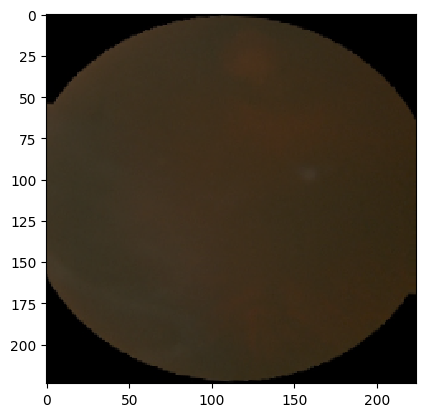

In [83]:
# lets take a look at a single augmented image

plt.imshow(train_image_data[0], interpolation='nearest')
plt.show()

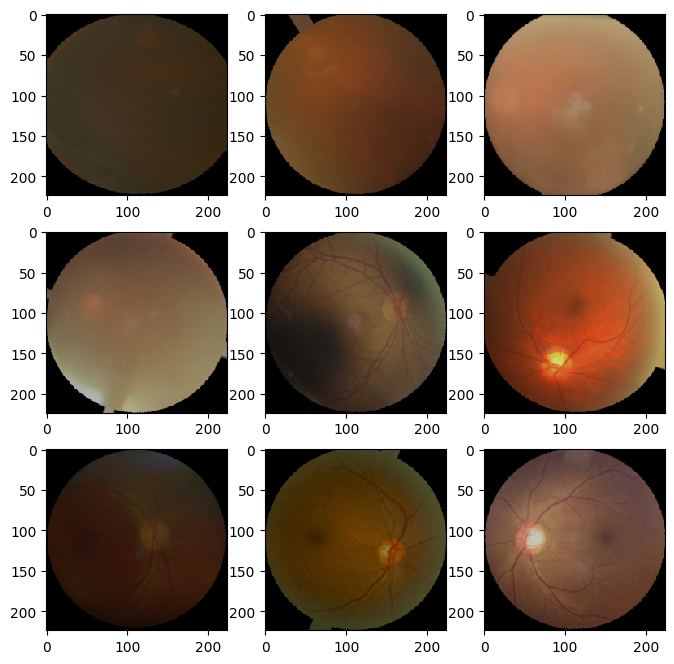

In [84]:
# lets make a grid of the data augmented images

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_image_data[i], interpolation='nearest')

plt.show()

# Building the Model

To build her transfer learning model, Dr. Iris utilizes the VGG16 architecture, a popular and highly effective CNN model. If a reader is interested in gaining better understanding of this architecture, Dr. Iris recommends [this](https://arxiv.org/abs/1409.1556) article. Since she is tailoring the model to the custom ODIR dataset with two output classes, she excludes the fully connected top layers of VGG16 using the include_top=False option. This allows her to customize the final layers to suit our specific classification task.

She leverages the pretrained imagenet weights for the convolutional base, which provide robust feature extraction capabilities. These weights, trained on a large-scale dataset, are optimized to detect edges, corners, and rounded areas—features that are universally relevant across image datasets. Using these pretrained filters allows Dr. Iris to speed up the training process and benefit from proven, high-quality feature maps.

To prevent overfitting, she incorporates a dropout layer, dropping 50% of the perceptrons in the final dense layer. Additionally, she uses the ADAM optimizer, an advanced gradient descent algorithm, to efficiently optimize our model during training.

In [86]:
# get VGG16 base model
vgg16 = keras.applications.vgg16.VGG16(input_shape=(224, 224, 3),
                                       weights='imagenet',
                                       include_top=False)

# add new dense layers at the top
x = keras.layers.Flatten()(vgg16.output)
x = keras.layers.Dense(1024, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(128, activation='relu')(x)

## remember we are using 2 outputs only
predictions = keras.layers.Dense(1, activation='sigmoid')(x)

# define and compile model
model = keras.Model(inputs=vgg16.inputs, outputs=predictions)
for layer in vgg16.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'Recall', Precision(), AUC(name='auc')])

For her model, Dr. Iris chose to implement both checkpointing and early stopping to enhance the training process and optimize model performance. A checkpoint allows her to monitor the model's accuracy during training and perform specific tasks when certain conditions are met. In this case, the checkpoint is configured to save the model as a file whenever it achieves its best validation accuracy, ensuring that the optimal version of the model is preserved.

Early stopping is used to monitor the model's accuracy over epochs based on a 'patience' parameter. If there is no improvement in accuracy within the specified number of consecutive epochs, the training process is automatically halted. This prevents unnecessary computation and reduces the risk of overfitting by stopping the training when further epochs are unlikely to yield significant performance gains. Together, these techniques ensure an efficient and effective training process while preserving the best-performing model for later use.

In [93]:
checkpoint = ModelCheckpoint(
    "vgg16_1.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto'
)


early = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0,
    patience=3,
    verbose=1,
    mode='auto'
)

The steps_per_epoch parameter determines how many batches of samples are processed to complete one full epoch during model training. This value depends on the batch size, which is defined when initializing the training data.  

The total number of steps per epoch is typically calculated as the total number of samples in the training set divided by the batch size, ensuring all data is seen once per epoch. This parameter is essential for controlling the training process and aligning it with the size of your dataset and batch configuration.

In [94]:
batch_size = 32
n_spe = train_generator.samples // batch_size # steps per epoch
n_val_steps = valid_generator.samples // batch_size # number of validation steps
n_epochs = 30

print(n_spe,n_val_steps)

22 5


In [95]:
# train the model

hist = model.fit(
    train_generator,
    steps_per_epoch=n_spe,
    validation_data=valid_generator,
    validation_steps=n_val_steps,
    epochs=n_epochs,
    shuffle=True,
    callbacks=[checkpoint, early]
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - Recall: 0.8372 - accuracy: 0.7877 - auc: 0.8944 - loss: 0.4276 - precision_1: 0.7755
Epoch 1: val_accuracy improved from -inf to 0.85000, saving model to vgg16_1.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 703ms/step - Recall: 0.8353 - accuracy: 0.7882 - auc: 0.8940 - loss: 0.4277 - precision_1: 0.7771 - val_Recall: 0.9737 - val_accuracy: 0.8500 - val_auc: 0.9521 - val_loss: 0.3602 - val_precision_1: 0.7708
Epoch 2/30
 1/22 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - Recall: 0.7895 - accuracy: 0.8438 - auc: 0.8381 - loss: 0.5318 - precision_1: 0.9375
Epoch 2: val_accuracy did not improve from 0.85000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Recall: 0.7895 - accuracy: 0.8438 - auc: 0.8381 - loss: 0.5318 - precision_1: 0.9375 - val_Recall: 1.0000 - val_accuracy: 0.8261 - val_auc: 0.9127 - val_loss: 0.4717 - val_precision_1: 0.6923
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - Recall: 0.7780 - accuracy: 0.7618 - auc: 0.8674 - loss: 0.4683 - 

Dr. Iris observes that the model stops early as the results do not show any improvement. She saves the model and visualizes the results.

In [96]:
# load saved model

model = load_model('./vgg16_1.keras')

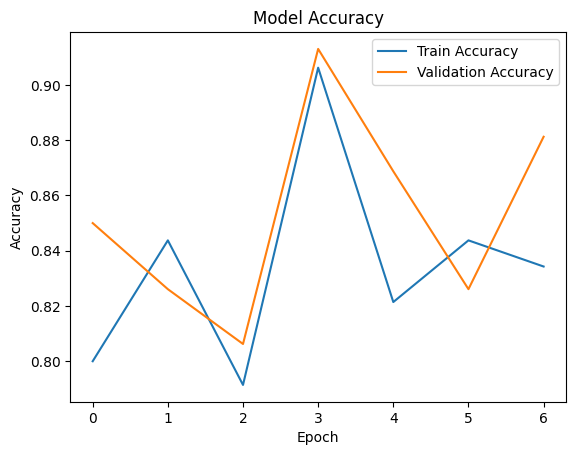

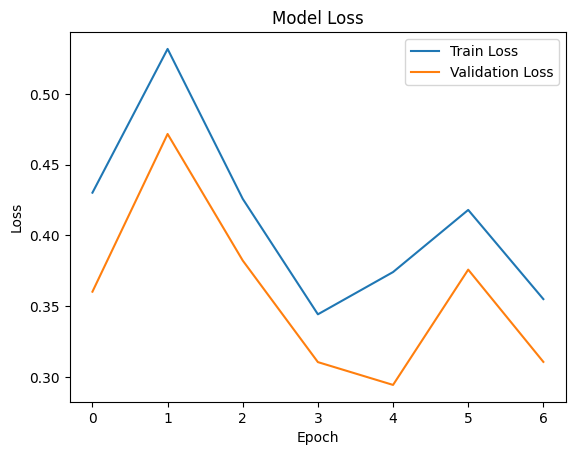

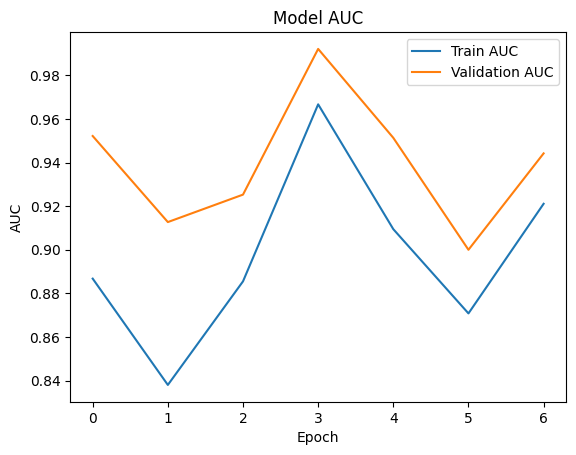

In [97]:
# Plot Accuracy
plt.plot(hist.history["accuracy"], label="Train Accuracy")
plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Plot Loss
plt.plot(hist.history['loss'], label="Train Loss")
plt.plot(hist.history['val_loss'], label="Validation Loss")
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Plot Recall
if 'recall' in hist.history:
    plt.plot(hist.history['recall'], label="Train Recall")
    plt.plot(hist.history['val_recall'], label="Validation Recall")
    plt.title("Model Recall")
    plt.ylabel("Recall")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

# Plot AUC
if 'auc' in hist.history:
    plt.plot(hist.history['auc'], label="Train AUC")
    plt.plot(hist.history['val_auc'], label="Validation AUC")
    plt.title("Model AUC")
    plt.ylabel("AUC")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()


# Making Predicitions

Using predict_generator, Dr. Iris can generate predictions for the test dataset by feeding batches of image data into the model through a generator. Before making predictions, the test generator is reset to ensure that no leftover image data from previous iterations is carried over. The output of the predictions consists of categorical labels, where 0 represents "Cataract" and 1 represents "Normal." It is important to note that the predictions output numerical labels rather than image data, providing classification results for the test images

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


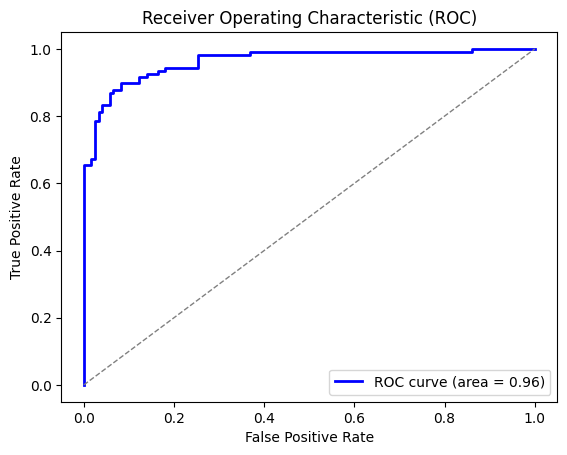

In [115]:
# Generate predictions and true labels
y_pred_prob = model.predict(test_generator)  # Predicted probabilities
y_true = test_generator.labels  # True labels from the generator

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


Dr. Iris sees that the AUC ROC metric is 0.96, which is a pretty good results. LEt's now do the predictions

In [116]:
steps = math.ceil(test_generator.samples / batch_size)

pred = model.predict(test_generator, verbose=1, steps=steps)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


In [117]:
# convert the data into 1s and 0s for simple classification

predicted_class_idx=np.argmax(pred,axis=1)

#print the same 10 rows

print(predicted_class_idx[0:10])
print(len(predicted_class_idx))

[0 0 0 0 0 0 0 0 0 0]
229


In [119]:
# Reset the generator (not always necessary, but good practice)
test_generator.reset()

# Evaluate the model
results = model.evaluate(test_generator, verbose=1)

# Print results
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Recall: {results[2]:.4f}")
print(f"Test AUC: {results[3]:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - Recall: 0.9384 - accuracy: 0.8402 - auc: 0.9592 - loss: 0.3690 - precision_1: 0.7636
Test Loss: 0.2330
Test Accuracy: 0.9039
Test Recall: 0.8718
Test AUC: 0.9358


In [120]:
# instead of 1s and 0s now, convert one-hot category labels to text labels

valid_generator.class_indices.items()

dict_items([('cataract', 0), ('normal', 1)])

Here, Dr. Iris uses the training label string names, "Cataract" and "Normal," to convert the one-hot encoded predicted class labels back into their corresponding string names. These lines of code map the predicted numerical values to their respective category names and store them in the predicted_labels variable, ensuring the output is human-readable and aligned with the original label categories.

In [103]:
valid_labels = dict((value,key) for key,value in valid_generator.class_indices.items())
pred_labels = [valid_labels[key] for key in predicted_class_idx]
pred_labels[1:10]


['cataract',
 'cataract',
 'cataract',
 'cataract',
 'cataract',
 'cataract',
 'cataract',
 'cataract',
 'cataract']

In [104]:
# create a new dataframe with filename and prediction

filenames = test_generator.filenames
prediction_df = pd.DataFrame({'Filename': filenames,'Prediction': pred_labels})
prediction_df.head()

,Filename,Prediction
0,3385_right.jpg,cataract
1,1452_left.jpg,cataract
2,1415_right.jpg,cataract
3,2560_left.jpg,cataract
4,2233_right.jpg,cataract


In [105]:
prediction_df.iloc[35]

,35
Filename,2135_left.jpg
Prediction,cataract


In [106]:
print(test_generator.filenames[35])
print(test_generator.labels[35])

2135_left.jpg
0


*Now* that Dr. Iris has verified that the test data and predictions are properly aligned, she can list all predictions and compare them to the actual test labels. This example is conducted using a small sample of the test dataset (just 10 samples) for simplicity and clarity.

In [123]:
test_file_names=test_generator.filenames  # sequential list of name of test files of each sample
test_labels=test_generator.labels # is a sequential list  of test labels for each image sample
class_dict= test_generator.class_indices # a dictionary where key is the class name and value is the label for the class

print (class_dict)

new_dict={}

for key in class_dict: # set key in new_dict to value in class_dict and value in new_dict to key in class_dict
    value = class_dict[key]
    new_dict[value] = key

print('  RESULT  PREDICT      TRUE CLASS       FILENAME ' )

for i, p in enumerate(pred[:10]):
    pred_index=np.argmax(p) # get the index that has the highest probability
    pred_class=new_dict[pred_index]  # find the predicted class based on the index
    true_class=new_dict[test_labels[i]] # use the test label to get the true class of the test file
    file=test_file_names[i]

    if true_class == pred_class:
        result = "Correct"
    else:
        result = "Wrong  "


    print(f' {result}   {pred_class}    {true_class}      {file}')

{'cataract': 0, 'normal': 1}
  RESULT  PREDICT      TRUE CLASS       FILENAME 
 Wrong     cataract    normal      3385_right.jpg
 Correct   cataract    cataract      1452_left.jpg
 Correct   cataract    cataract      1415_right.jpg
 Wrong     cataract    normal      2560_left.jpg
 Correct   cataract    cataract      2233_right.jpg
 Correct   cataract    cataract      2117_left.jpg
 Wrong     cataract    normal      3359_right.jpg
 Correct   cataract    cataract      1084_right.jpg
 Correct   cataract    cataract      2181_right.jpg
 Correct   cataract    cataract      2118_right.jpg


Here Dr. Iris has retrieve a batch of test images and their corresponding labels from the test generator, then examine a specific sample by printing its filename, true label, and predicted label. It ensures the test data, labels, and predictions are correctly aligned for validation and debugging.

In [124]:
test_image_data, test_labels = next(test_generator)

print(test_image_data.shape)
print(test_labels.shape)

z = 0
test_file_names=test_generator.filenames[z]
print(test_file_names)

test_labels_example=test_generator.labels[z]
print(test_labels_example)

pred_labels[z]

(32, 224, 224, 3)
(32,)
3385_right.jpg
1


'cataract'

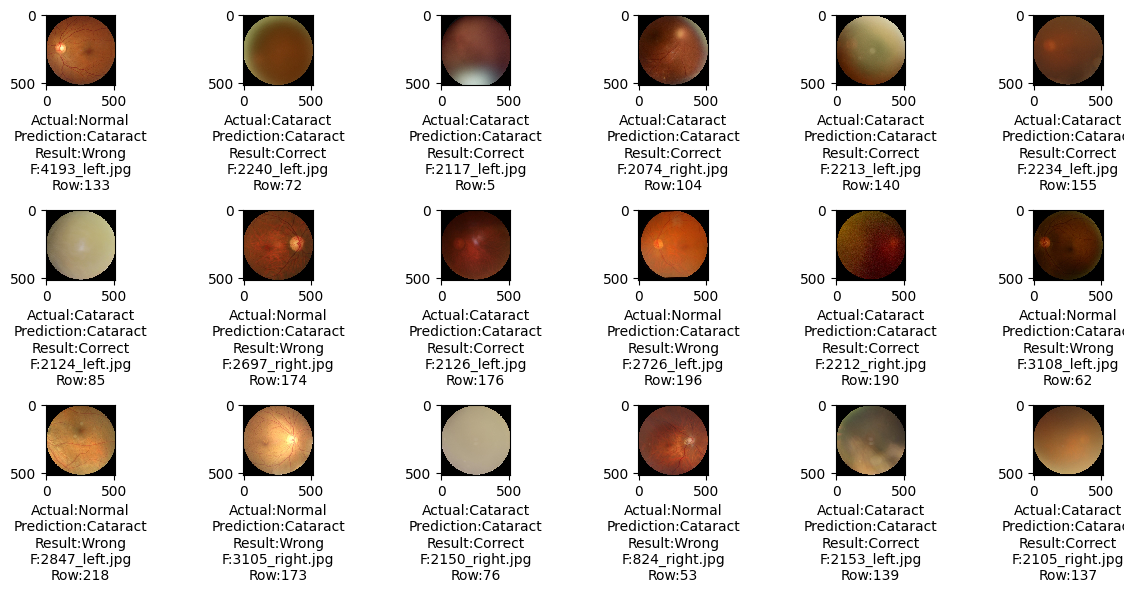

In [125]:
# plot our comparison grid

plt.figure(figsize=(12,6))
for i in range(18):
    sample = random.choice(range(test_generator.samples))

    img = test_generator.filenames[sample]
    image = cv2.imread(os.path.join(image_dir, img))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    category = test_generator.labels[sample]
    pred_category = pred_labels[sample]

    if category== 1:
        label = "Normal"
    else:
        label = "Cataract"

    if pred_category== "normal":
        pred_label = "Normal"
    else:
        pred_label = "Cataract"

    if label == pred_label:
        result = "Correct"
    else:
        result = "Wrong"


    plt.subplot(3,6,i+1)
    plt.imshow(image_rgb, interpolation='nearest')
    plt.xlabel("Actual:{}\nPrediction:{}\nResult:{}\nF:{}\nRow:{}".format(label,
                                                                          pred_label,
                                                                          result,
                                                                          test_generator.filenames[sample],
                                                                          sample))
plt.tight_layout()

# Confusion matrix

Dr. Iris creates a confusion matrix to gain deeper understanding of the wrong answers distribution.

In [126]:
cm = confusion_matrix(test_generator.labels, predicted_class_idx)
print('Confusion Matrix')
cm

Confusion Matrix


array([[99,   15],
       [10,   105]])

In [127]:
def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
cm_plot_labels = ['cataract','normal']

Confusion matrix, without normalization
[[99   15]
 [10   105]]


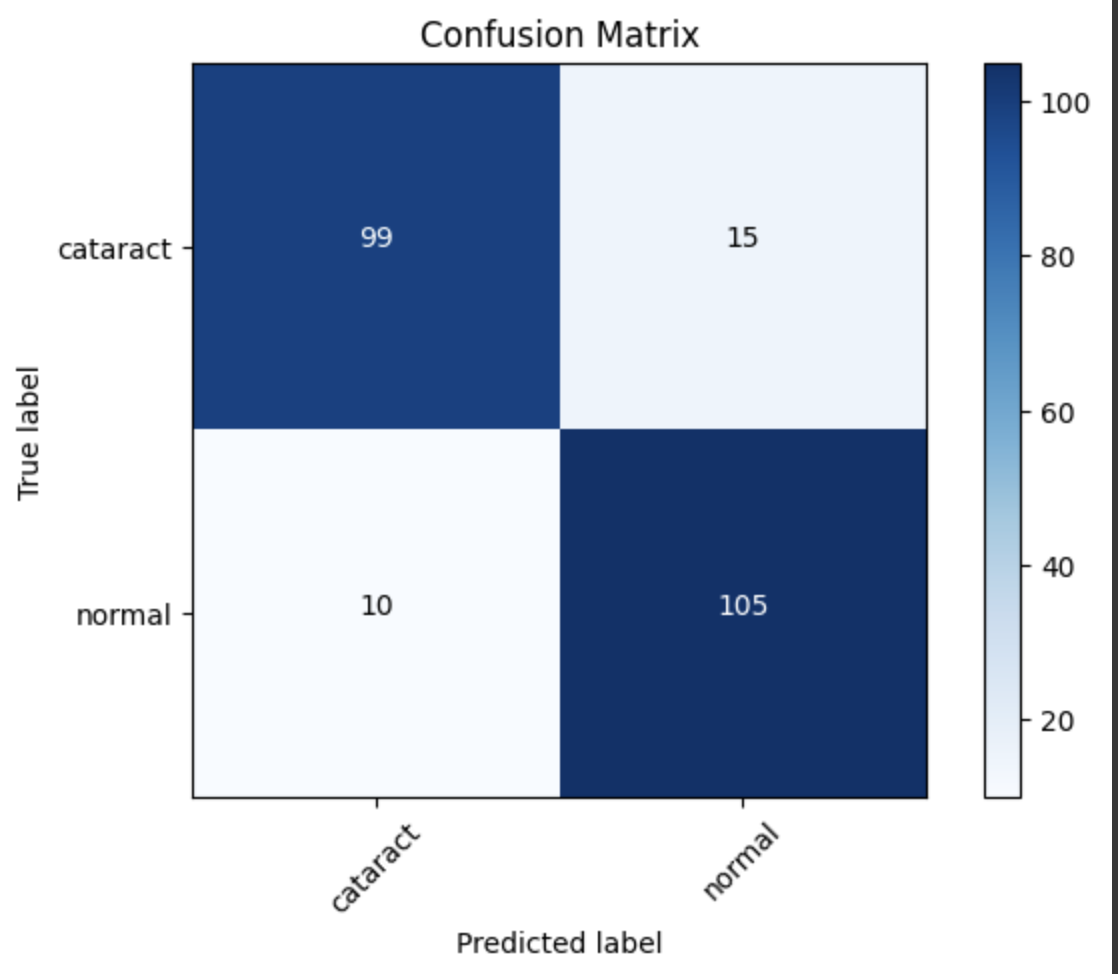

In [113]:
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')